##**Predicción del Estado de Bombas de Agua en Tanzania**

---


###Machine Learning - Práctica UCM

### Contexto del Problema
Tanzania enfrenta un desafío crítico en el mantenimiento de su infraestructura hídrica: determinar el estado operativo de miles de bombas de agua distribuidas por todo el país. Este proyecto desarrolló un sistema de machine learning para predecir automáticamente si una bomba está funcional, no funcional, o necesita reparación.

### Objetivos del Proyecto
- Desarrollar modelos predictivos para clasificar el estado de bombas de agua
- Identificar los factores más influyentes en el funcionamiento de la infraestructura
- Validar la efectividad mediante competencia internacional en DrivenData

In [ ]:
# Predicción del Estado de Bombas de Agua en Tanzania
# Machine Learning - Práctica UCM

# Importación de Librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Modelado
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.impute import SimpleImputer

# Para manejo de desbalance
from imblearn.over_sampling import SMOTE
from collections import Counter

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

In [ ]:
# Carga de Datos

train_values = pd.read_csv('train_set_values.csv')
train_labels = pd.read_csv('train_set_labels.csv')
test_values = pd.read_csv('test_set_values.csv')

In [ ]:
# Unir datos de entrenamiento con etiquetas
train_data = pd.merge(train_values, train_labels, on='id')

print("Dimensiones de los datasets:")
print(f"Train: {train_data.shape}")
print(f"Test: {test_values.shape}")
print(f"\nPrimeras filas del dataset de entrenamiento:")
train_data.head()

Dimensiones de los datasets:
Train: (59400, 41)
Test: (14850, 40)

Primeras filas del dataset de entrenamiento:


,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,scheme_name,permit,construction_year,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,Lake Nyasa,Mnyusi B,Iringa,11,5,Ludewa,Mundindi,109,True,GeoData Consultants Ltd,VWC,Roman,False,1999,gravity,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,Lake Victoria,Nyamara,Mara,20,2,Serengeti,Natta,280,NaN,GeoData Consultants Ltd,Other,NaN,True,2010,gravity,gravity,gravity,wug,user-group,never pay,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,Pangani,Majengo,Manyara,21,4,Simanjiro,Ngorika,250,True,GeoData Consultants Ltd,VWC,Nyumba ya mungu pipe scheme,True,2009,gravity,gravity,gravity,vwc,user-group,pay per bucket,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,Ruvuma / Southern Coast,Mahakamani,Mtwara,90,63,Nanyumbu,Nanyumbu,58,True,GeoData Consultants Ltd,VWC,NaN,True,1986,submersible,submersible,submersible,vwc,user-group,never pay,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,Lake Victoria,Kyanyamisa,Kagera,18,1,Karagwe,Nyakasimbi,0,True,GeoData Consultants Ltd,NaN,NaN,True,0,gravity,gravity,gravity,other,other,never pay,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27910 entries, 0 to 27909
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     27910 non-null  int64  
 1   amount_tsh             27910 non-null  float64
 2   date_recorded          27910 non-null  object 
 3   funder                 26232 non-null  object 
 4   gps_height             27910 non-null  int64  
 5   installer              26221 non-null  object 
 6   longitude              27910 non-null  float64
 7   latitude               27910 non-null  float64
 8   wpt_name               27909 non-null  object 
 9   num_private            27910 non-null  int64  
 10  basin                  27910 non-null  object 
 11  subvillage             27735 non-null  object 
 12  region                 27910 non-null  object 
 13  region_code            27910 non-null  int64  
 14  district_code          27910 non-null  int64  
 15  lg

## Análisis Exploratorio de Datos (EDA)

### 1. Distribución de la Variable Objetivo



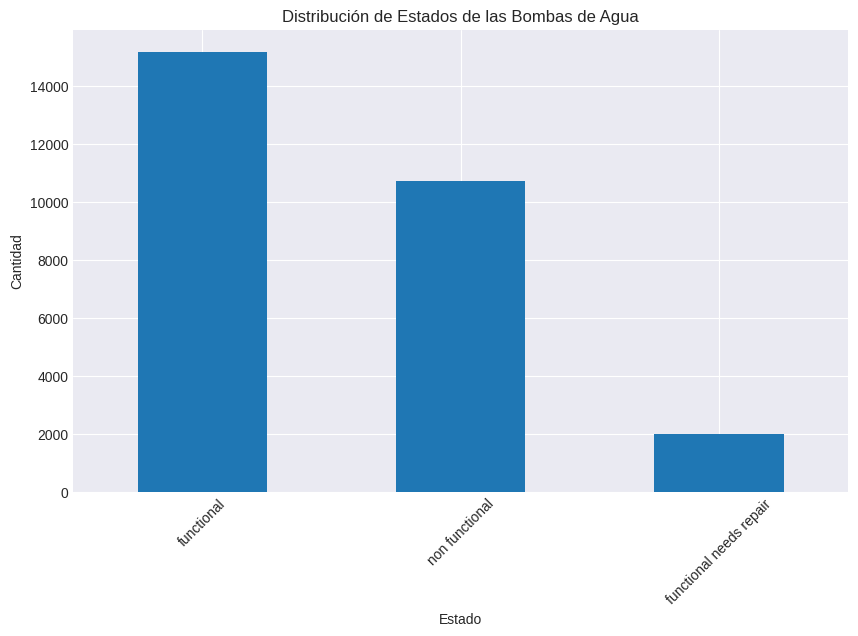

Distribución porcentual de las clases:
status_group
functional                 54.403440
non functional             38.434253
functional needs repair     7.162307
Name: proportion, dtype: float64


In [ ]:
## Análisis Exploratorio de Datos (EDA)

### Distribución de la Variable Objetivo

# Distribución de las clases
plt.figure(figsize=(10, 6))
train_data['status_group'].value_counts().plot(kind='bar')
plt.title('Distribución de Estados de las Bombas de Agua')
plt.xlabel('Estado')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

# Porcentajes exactos
print("Distribución porcentual de las clases:")
class_distribution = train_data['status_group'].value_counts(normalize=True) * 100
print(class_distribution)

La variable objetivo status_group tiene una distribución desbalanceada: 54.3% de los puntos de agua son funcionales, 38.4% no funcionan y solo 7.3% necesitan reparación. Este desbalance podria afectar negativamente el rendimiento del modelo, especialmente al predecir la clase minoritaria ("functional needs repair"). Por lo tanto se podria considerar usar tecnicas, como el reequilibrio de clases o el ajuste de pesos en los algoritmos para mejorar la capacidad del modelo y que este pueda distinguir correctamente entre las tres clases.

### 2. Análisis de Valores Faltantes

In [ ]:
#Análisis de Valores Faltantes

# Verificar valores faltantes
missing_values = train_data.isnull().sum()
missing_percent = (missing_values / len(train_data)) * 100
missing_df = pd.DataFrame({
    'Columna': missing_values.index,
    'Valores_Faltantes': missing_values.values,
    'Porcentaje': missing_percent.values
})
missing_df = missing_df[missing_df['Valores_Faltantes'] > 0].sort_values('Porcentaje', ascending=False)
print("\nValores faltantes por columna:")
print(missing_df)



Valores faltantes por columna:
                  Columna  Valores_Faltantes  Porcentaje
21            scheme_name              13567   48.609817
20      scheme_management               1856    6.649946
5               installer               1689    6.051594
3                  funder               1678    6.012182
18         public_meeting               1614    5.782874
22                 permit               1428    5.116446
11             subvillage                175    0.627015
8                wpt_name                  1    0.003583
34         quantity_group                  1    0.003583
35                 source                  1    0.003583
36            source_type                  1    0.003583
37           source_class                  1    0.003583
38        waterpoint_type                  1    0.003583
39  waterpoint_type_group                  1    0.003583


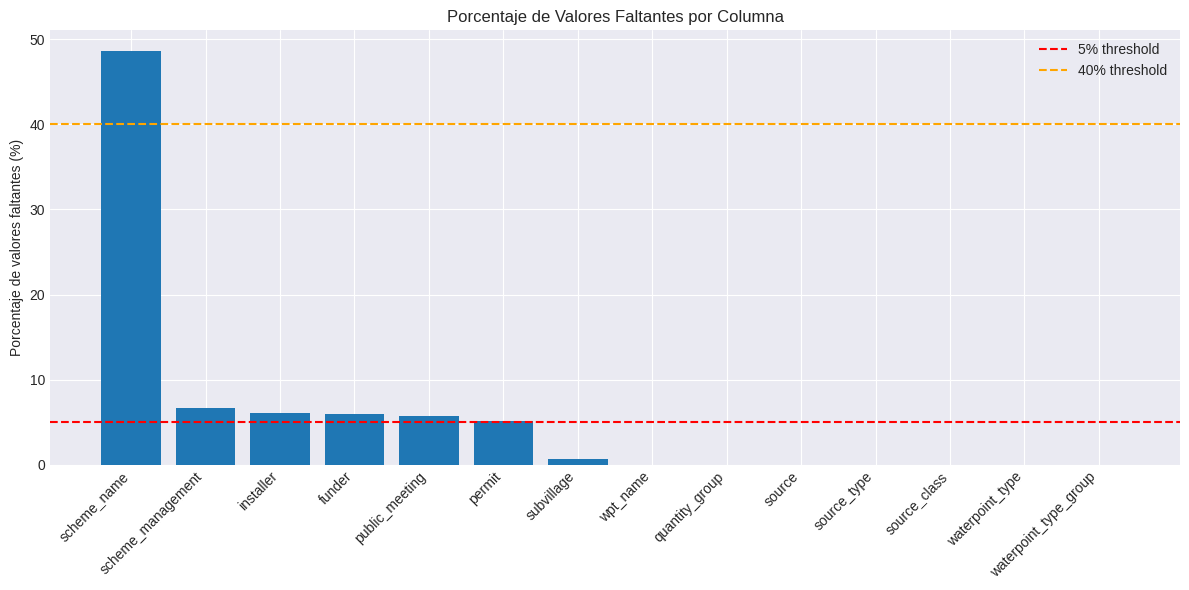

In [ ]:
# Visualizar valores faltantes
plt.figure(figsize=(12, 6))
missing_df_plot = missing_df[missing_df['Porcentaje'] > 0]
plt.bar(range(len(missing_df_plot)), missing_df_plot['Porcentaje'])
plt.xticks(range(len(missing_df_plot)), missing_df_plot['Columna'], rotation=45, ha='right')
plt.ylabel('Porcentaje de valores faltantes (%)')
plt.title('Porcentaje de Valores Faltantes por Columna')
plt.axhline(y=5, color='r', linestyle='--', label='5% threshold')
plt.axhline(y=40, color='orange', linestyle='--', label='40% threshold')
plt.legend()
plt.tight_layout()
plt.show()

Algunas columnas del dataset tienen valores faltantes, destacando scheme_name con casi el 49% de datos ausentes, lo que sugiere que podría ser descartada o imputada con cuidado. Otras variables como scheme_management, installer, funder, public_meeting y permit tienen entre 5% y 6.5% de valores faltantes, lo que requiere imputación adecuada. Las columnas subvillage y wpt_name tienen pocos valores nulos, por lo que pueden imputarse fácilmente sin gran impacto.

###3. Análisis de Variables Numéricas


In [ ]:
#Análisis de Variables Numéricas

# Variables numéricas
numeric_cols = train_data.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('id')
print("\nVariables numéricas:")
print(numeric_cols)

# Estadísticas descriptivas
train_data[numeric_cols].describe()


Variables numéricas:
['amount_tsh', 'gps_height', 'longitude', 'latitude', 'num_private', 'region_code', 'district_code', 'population', 'construction_year']


,amount_tsh,gps_height,longitude,latitude,num_private,region_code,district_code,population,construction_year
count,27910.000000,27910.000000,27910.000000,2.791000e+04,27910.000000,27910.000000,27910.000000,27910.000000,27910.000000
mean,328.036209,667.643784,34.111641,-5.710309e+00,0.492942,15.410570,5.647402,179.300967,1302.302580
std,3593.208400,692.531340,6.539678,2.950510e+00,13.757962,17.772359,9.625108,463.375092,951.151109
min,0.000000,-63.000000,0.000000,-1.158630e+01,0.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,33.108959,-8.564086e+00,0.000000,5.000000,2.000000,0.000000,0.000000
50%,0.000000,371.000000,34.916438,-5.025370e+00,0.000000,12.000000,3.000000,25.000000,1986.000000
75%,25.000000,1319.000000,37.201936,-3.324254e+00,0.000000,17.000000,5.000000,212.000000,2004.000000
max,350000.000000,2770.000000,40.345193,-2.000000e-08,1776.000000,99.000000,80.000000,15300.000000,2013.000000


Las variables numéricas muestran una alta dispersión y presencia de valores atípicos, especialmente en amount_tsh, population y num_private, con máximos muy alejados de la media, lo que puede afectar el rendimiento de algunos modelos si no se normalizan o transforman. También hay posibles errores o valores inválidos, como longitude y gps_height con ceros o negativos, y construction_year con ceros que indican valores faltantes. Estos aspectos seran tratados en la fase de preprocesamiento para mejorar la calidad del modelo y evitar sesgos.

In [ ]:
# Análisis detallado de problemas en variables numéricas
print("\n ANÁLISIS DE PROBLEMAS EN VARIABLES NUMÉRICAS:")

# 1. amount_tsh (Total static head)
print("\n1. amount_tsh:")
print(f"   - Ceros: {(train_data['amount_tsh'] == 0).sum()} ({(train_data['amount_tsh'] == 0).sum()/len(train_data)*100:.1f}%)")
print(f"   - Valores extremos (>10000): {(train_data['amount_tsh'] > 10000).sum()}")

# 2. GPS coordinates
print("\n2. Coordenadas GPS:")
gps_zeros = ((train_data['longitude'] == 0) & (train_data['latitude'] == 0)).sum()
print(f"   - GPS inválido (0,0): {gps_zeros} ({gps_zeros/len(train_data)*100:.1f}%)")
print(f"   - gps_height negativos: {(train_data['gps_height'] < 0).sum()}")

# 3. population
print("\n3. Population:")
print(f"   - Población = 0: {(train_data['population'] == 0).sum()} ({(train_data['population'] == 0).sum()/len(train_data)*100:.1f}%)")
print(f"   - Población > 10000: {(train_data['population'] > 10000).sum()}")

# 4. construction_year
print("\n4. Construction year:")
print(f"   - Año = 0: {(train_data['construction_year'] == 0).sum()} ({(train_data['construction_year'] == 0).sum()/len(train_data)*100:.1f}%)")
print(f"   - Años futuros (>2013): {(train_data['construction_year'] > 2013).sum()}")



 ANÁLISIS DE PROBLEMAS EN VARIABLES NUMÉRICAS:

1. amount_tsh:
   - Ceros: 19516 (69.9%)
   - Valores extremos (>10000): 82

2. Coordenadas GPS:
   - GPS inválido (0,0): 0 (0.0%)
   - gps_height negativos: 695

3. Population:
   - Población = 0: 10020 (35.9%)
   - Población > 10000: 1

4. Construction year:
   - Año = 0: 9708 (34.8%)
   - Años futuros (>2013): 0


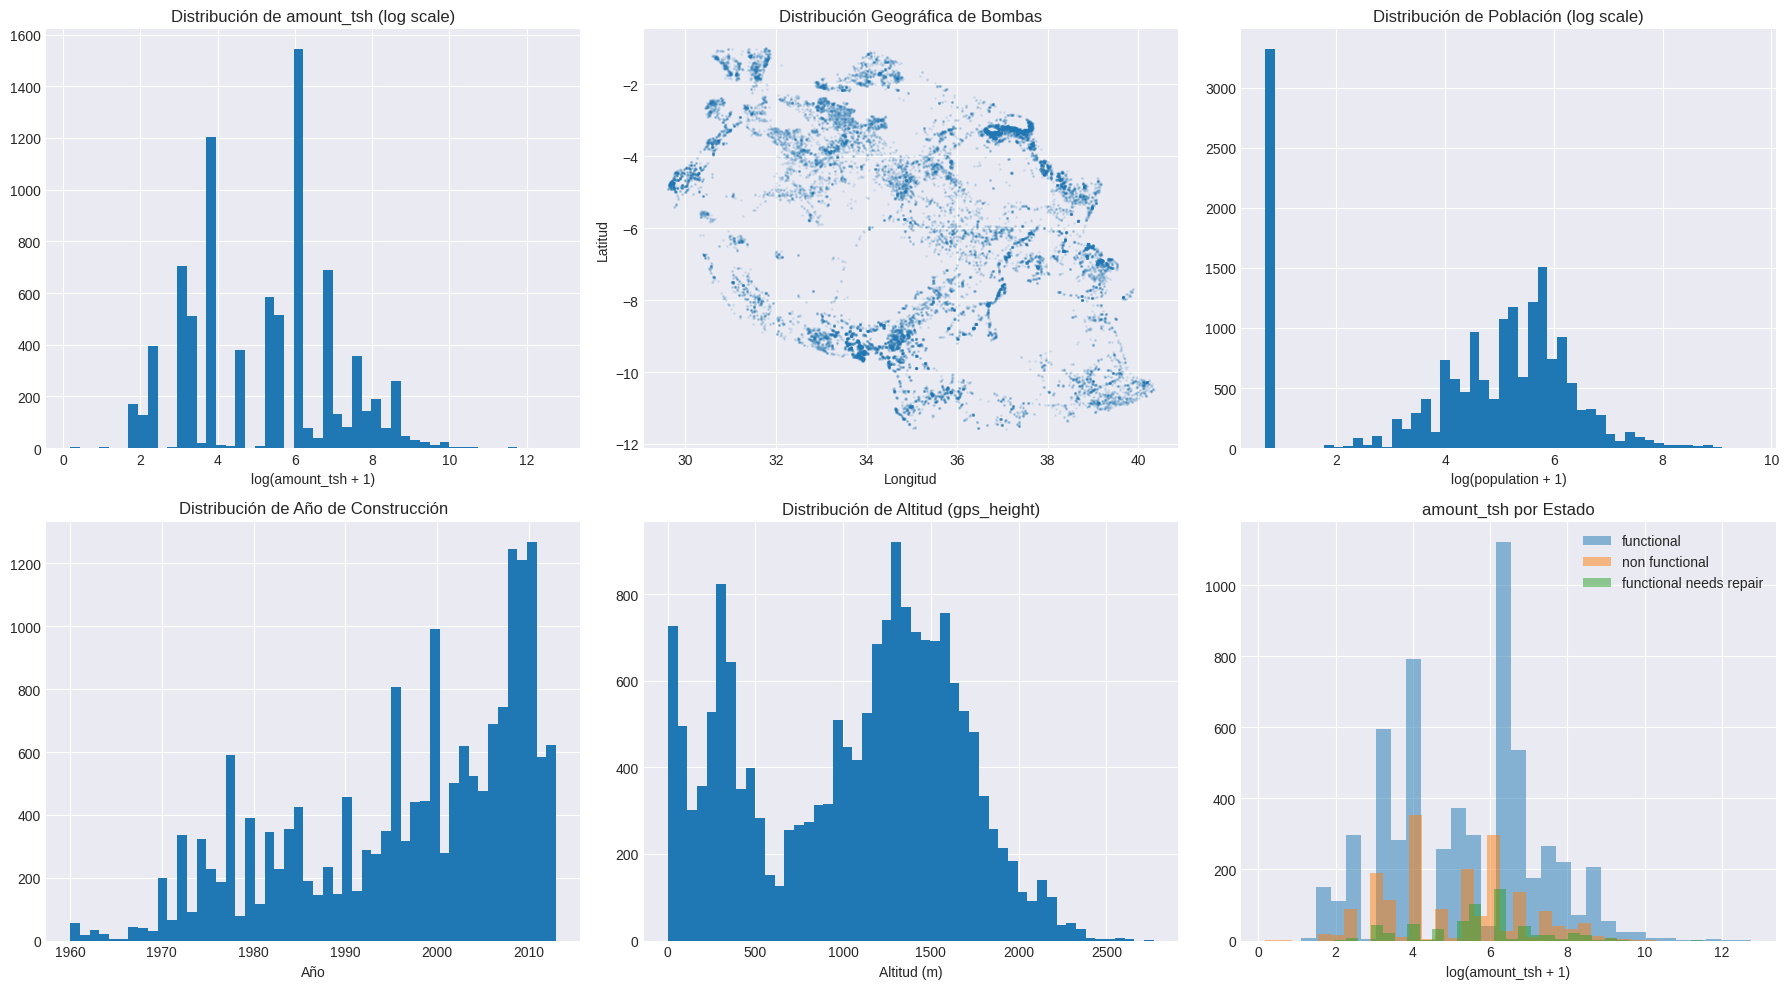

In [ ]:
# Visualizaciones
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

# 1. Distribución de amount_tsh (log scale)
train_data[train_data['amount_tsh'] > 0]['amount_tsh'].apply(np.log1p).hist(bins=50, ax=axes[0])
axes[0].set_title('Distribución de amount_tsh (log scale)')
axes[0].set_xlabel('log(amount_tsh + 1)')

# 2. Mapa de coordenadas GPS
valid_gps = train_data[(train_data['longitude'] != 0) & (train_data['latitude'] != 0)]
axes[1].scatter(valid_gps['longitude'], valid_gps['latitude'], alpha=0.1, s=1)
axes[1].set_title('Distribución Geográfica de Bombas')
axes[1].set_xlabel('Longitud')
axes[1].set_ylabel('Latitud')

# 3. Distribución de population (log scale)
train_data[train_data['population'] > 0]['population'].apply(np.log1p).hist(bins=50, ax=axes[2])
axes[2].set_title('Distribución de Población (log scale)')
axes[2].set_xlabel('log(population + 1)')

# 4. Distribución de construction_year
train_data[train_data['construction_year'] > 0]['construction_year'].hist(bins=50, ax=axes[3])
axes[3].set_title('Distribución de Año de Construcción')
axes[3].set_xlabel('Año')

# 5. gps_height
train_data[train_data['gps_height'] > 0]['gps_height'].hist(bins=50, ax=axes[4])
axes[4].set_title('Distribución de Altitud (gps_height)')
axes[4].set_xlabel('Altitud (m)')

# 6. Relación amount_tsh vs status_group
for status in train_data['status_group'].unique():
    subset = train_data[train_data['status_group'] == status]
    subset_positive = subset[subset['amount_tsh'] > 0]['amount_tsh'].apply(np.log1p)
    axes[5].hist(subset_positive, bins=30, alpha=0.5, label=status)
axes[5].set_title('amount_tsh por Estado')
axes[5].set_xlabel('log(amount_tsh + 1)')
axes[5].legend()

plt.tight_layout()
plt.show()

Los gráficos muestran que **amount_tsh** y **population** tienen distribuciones altamente sesgadas, con muchos ceros y una concentración de valores bajos, lo cual se suaviza al aplicar escala logarítmica. La variable **construction_year** tiene una gran acumulación reciente pero también muchos ceros (antes de 1960 prácticamente no hay datos). La **gps_height** presenta múltiples picos, incluyendo altitudes cercanas a cero que podrían ser errores. **La distribución geográfica de las bombas** cubre bien el país(las bombas están bien distribuidas geográficamente, muchas se construyeron entre 2000 y 2010, y la mayoría están en zonas montañosas con altitudes entre 1000 y 1500 metros.), y al descomponer **amount_tsh por estado**, se observan diferencias notables entre clases, lo cual sugiere que esta variable puede ser útil para predecir el estado del punto de agua. Estos patrones ayudan a identificar qué variables necesitan transformación o limpieza para mejorar el modelo.

In [ ]:
# Análisis de correlación con target
print("\nCorrelación de ceros/missings con el estado de la bomba:")
zero_analysis = pd.DataFrame({
    'amount_tsh_zero': train_data['amount_tsh'] == 0,
    'population_zero': train_data['population'] == 0,
    'gps_invalid': (train_data['longitude'] == 0) & (train_data['latitude'] == 0),
    'construction_year_zero': train_data['construction_year'] == 0,
    'status_group': train_data['status_group']
})

for col in ['amount_tsh_zero', 'population_zero', 'gps_invalid', 'construction_year_zero']:
    print(f"\n{col}:")
    crosstab = pd.crosstab(zero_analysis[col], zero_analysis['status_group'], normalize='columns')
    print(crosstab.round(3))


Correlación de ceros/missings con el estado de la bomba:

amount_tsh_zero:
status_group     functional  functional needs repair  non functional
amount_tsh_zero                                                     
False                 0.391                    0.293           0.174
True                  0.609                    0.707           0.826

population_zero:
status_group     functional  functional needs repair  non functional
population_zero                                                     
False                 0.651                    0.585           0.637
True                  0.349                    0.415           0.363

gps_invalid:
status_group  functional  functional needs repair  non functional
gps_invalid                                                      
False                1.0                      1.0             1.0

construction_year_zero:
status_group            functional  functional needs repair  non functional
construction_year_zero                   

El análisis de correlación muestra que los valores cero o faltantes en variables numéricas están asociados a estados negativos de las bombas: el 83% de las bombas no funcionales tienen **amount_tsh** igual a cero(Esto indica que si una bomba no tiene agua, probablemente esté rota), y el 36.5% tienen **population** cero pero estos podrían ser reales en zonas remotas, y su impacto es bajo. También, los valores faltantes en **construction_year** (valor cero) son más frecuentes en bombas que no funcionan o necesitan reparación, mientras que las coordenadas GPS inválidas no afectan, ya que no hay casos con (0,0). Estas relaciones sugieren que los ceros en estas variables no son aleatorios y podrían ser indicativos de mal estado, por lo que conservar esta información o crear variables binarias que capturen estos patrones puede mejorar la capacidad predictiva del modelo.

### 4. Análisis de Variables Categóricas

In [ ]:
### Análisis de Variables Categóricas

# Variables categóricas
categorical_cols = train_data.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('status_group')

print("\nVariables categóricas y su cardinalidad:")
cardinality_df = pd.DataFrame({
    'variable': categorical_cols,
    'cardinality': [train_data[col].nunique() for col in categorical_cols]
}).sort_values('cardinality', ascending=False)

for _, row in cardinality_df.iterrows():
    print(f"{row['variable']}: {row['cardinality']} valores únicos")


Variables categóricas y su cardinalidad:
wpt_name: 19159 valores únicos
subvillage: 12741 valores únicos
scheme_name: 2169 valores únicos
ward: 2045 valores únicos
installer: 1463 valores únicos
funder: 1308 valores únicos
date_recorded: 332 valores únicos
lga: 125 valores únicos
region: 21 valores únicos
extraction_type: 17 valores únicos
extraction_type_group: 13 valores únicos
management: 12 valores únicos
scheme_management: 11 valores únicos
source: 10 valores únicos
basin: 9 valores únicos
water_quality: 8 valores únicos
payment_type: 7 valores únicos
source_type: 7 valores únicos
waterpoint_type: 7 valores únicos
extraction_type_class: 7 valores únicos
payment: 7 valores únicos
waterpoint_type_group: 6 valores únicos
quantity: 6 valores únicos
quality_group: 6 valores únicos
quantity_group: 5 valores únicos
management_group: 5 valores únicos
source_class: 3 valores únicos
public_meeting: 2 valores únicos
permit: 2 valores únicos
recorded_by: 1 valores únicos


El dataset contiene muchas variables categóricas con alta cardinalidad, como wpt_name, subvillage, scheme_name, installer y funder, que tienen miles de valores únicos y probablemente no aporten valor predictivo directo, por lo que conviene agrupar, codificar los más frecuentes o eliminarlas. En cambio, variables con cardinalidad media o baja como extraction_type, management, source, water_quality y payment_type son más manejables y potencialmente útiles para el modelo. También hay variables binarias (public_meeting, permit) y constantes (recorded_by) que deben ser tratadas según su relevancia. Reducir la dimensionalidad de estas variables ayudaria a evitar sobreajuste y mejora la eficiencia del modelo.

In [ ]:
# Clasificar variables por cardinalidad
very_high_card = cardinality_df[cardinality_df['cardinality'] > 1000]['variable'].tolist()
high_card = cardinality_df[(cardinality_df['cardinality'] > 50) & (cardinality_df['cardinality'] <= 1000)]['variable'].tolist()
medium_card = cardinality_df[(cardinality_df['cardinality'] > 10) & (cardinality_df['cardinality'] <= 50)]['variable'].tolist()
low_card = cardinality_df[cardinality_df['cardinality'] <= 10]['variable'].tolist()

print("\nCLASIFICACIÓN POR CARDINALIDAD:")
print(f"\nMuy Alta (>1000): {very_high_card}")
print(f"Alta (51-1000): {high_card}")
print(f"Media (11-50): {medium_card}")
print(f"Baja (≤10): {low_card}")



CLASIFICACIÓN POR CARDINALIDAD:

Muy Alta (>1000): ['wpt_name', 'subvillage', 'scheme_name', 'ward', 'installer', 'funder']
Alta (51-1000): ['date_recorded', 'lga']
Media (11-50): ['region', 'extraction_type', 'extraction_type_group', 'management', 'scheme_management']
Baja (≤10): ['source', 'basin', 'water_quality', 'payment_type', 'source_type', 'waterpoint_type', 'extraction_type_class', 'payment', 'waterpoint_type_group', 'quantity', 'quality_group', 'quantity_group', 'management_group', 'source_class', 'public_meeting', 'permit', 'recorded_by']


In [ ]:
# Análisis de variables redundantes
print("\nANÁLISIS DE REDUNDANCIA:")
redundant_groups = [
    ['extraction_type', 'extraction_type_group', 'extraction_type_class'],
    ['management', 'management_group'],
    ['payment', 'payment_type'],
    ['water_quality', 'quality_group'],
    ['quantity', 'quantity_group'],
    ['source', 'source_type', 'source_class'],
    ['waterpoint_type', 'waterpoint_type_group']
]

for group in redundant_groups:
    print(f"\nGrupo: {group[0].split('_')[0]}")
    for var in group:
        print(f"  - {var}: {train_data[var].nunique()} valores")



ANÁLISIS DE REDUNDANCIA:

Grupo: extraction
  - extraction_type: 17 valores
  - extraction_type_group: 13 valores
  - extraction_type_class: 7 valores

Grupo: management
  - management: 12 valores
  - management_group: 5 valores

Grupo: payment
  - payment: 7 valores
  - payment_type: 7 valores

Grupo: water
  - water_quality: 8 valores
  - quality_group: 6 valores

Grupo: quantity
  - quantity: 6 valores
  - quantity_group: 5 valores

Grupo: source
  - source: 10 valores
  - source_type: 7 valores
  - source_class: 3 valores

Grupo: waterpoint
  - waterpoint_type: 7 valores
  - waterpoint_type_group: 6 valores


El análisis identifica siete grupos de variables que presentan información redundante o jerárquica, donde cada grupo contiene variables que describen el mismo concepto a diferentes niveles de granularidad. Por ejemplo, el grupo de extracción tiene extraction_type (18 valores) como la versión más específica, extraction_type_group (13 valores) como intermedia, y extraction_type_class (7 valores) como la más general. Esta redundancia puede causar multicolinealidad en el modelo y aumentar innecesariamente la dimensionalidad del dataset. Para optimizar el modelo predictivo, se recomienda seleccionar solo una variable por grupo, priorizando aquellas con granularidad intermedia que mantengan suficiente información discriminativa sin ser excesivamente específicas, como extraction_type_group, management_group, quality_group, y source_type, lo que reduciría las 21 variables redundantes a solo 7 variables representativas.

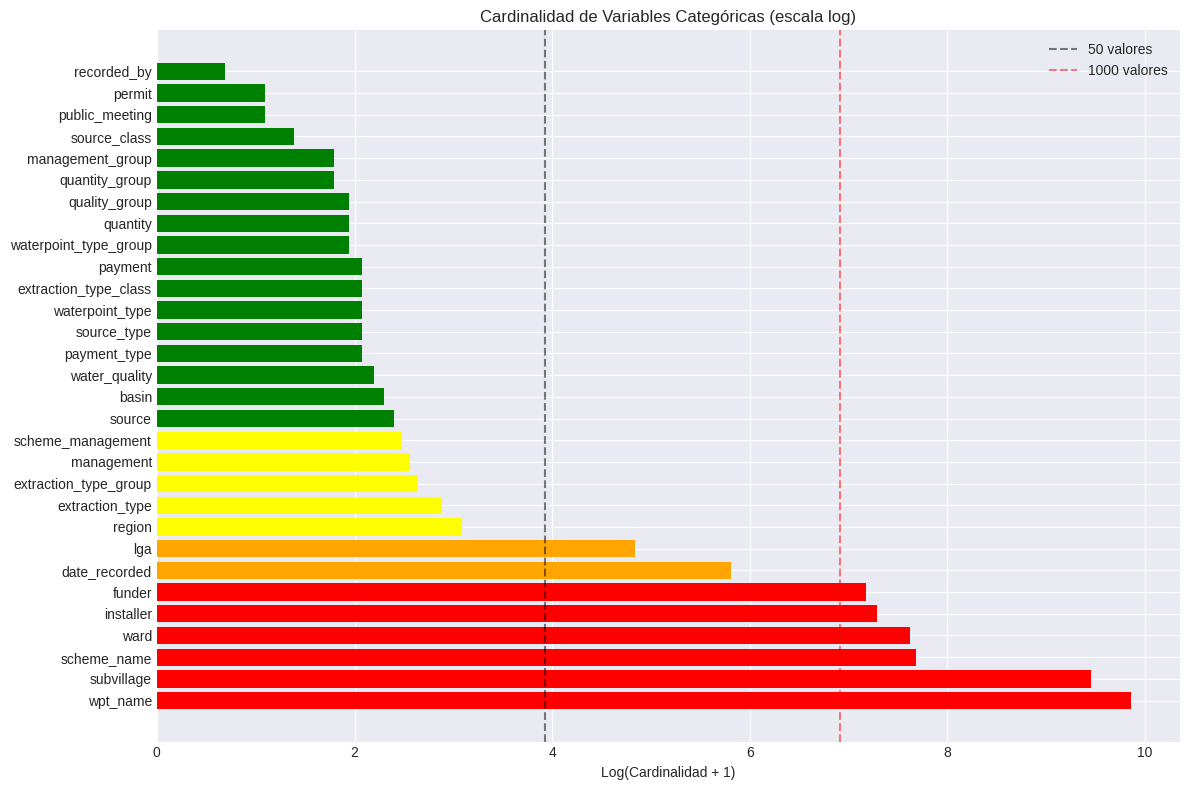

In [ ]:
# Visualización de cardinalidad
plt.figure(figsize=(12, 8))
cardinality_df_plot = cardinality_df.copy()
cardinality_df_plot['log_cardinality'] = np.log1p(cardinality_df_plot['cardinality'])

colors = ['red' if x in very_high_card else 'orange' if x in high_card else 'yellow' if x in medium_card else 'green'
          for x in cardinality_df_plot['variable']]

plt.barh(range(len(cardinality_df_plot)), cardinality_df_plot['log_cardinality'], color=colors)
plt.yticks(range(len(cardinality_df_plot)), cardinality_df_plot['variable'])
plt.xlabel('Log(Cardinalidad + 1)')
plt.title('Cardinalidad de Variables Categóricas (escala log)')
plt.axvline(x=np.log1p(50), color='black', linestyle='--', alpha=0.5, label='50 valores')
plt.axvline(x=np.log1p(1000), color='red', linestyle='--', alpha=0.5, label='1000 valores')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Análisis específico de variables de muy alta cardinalidad
print("\nANÁLISIS DETALLADO DE VARIABLES PROBLEMÁTICAS:")

for col in ['wpt_name', 'subvillage', 'ward', 'scheme_name', 'funder', 'installer']:
    if col in train_data.columns:
        value_counts = train_data[col].value_counts()
        print(f"\n{col}:")
        print(f"  - Valores únicos: {train_data[col].nunique()}")
        print(f"  - Top 10 representan: {value_counts.head(10).sum() / len(train_data) * 100:.1f}% de los datos")
        print(f"  - Top 20 representan: {value_counts.head(20).sum() / len(train_data) * 100:.1f}% de los datos")
        print(f"  - Valores con 1 sola aparición: {(value_counts == 1).sum()}")



ANÁLISIS DETALLADO DE VARIABLES PROBLEMÁTICAS:

wpt_name:
  - Valores únicos: 19159
  - Top 10 representan: 13.4% de los datos
  - Top 20 representan: 15.4% de los datos
  - Valores con 1 sola aparición: 17376

subvillage:
  - Valores únicos: 12741
  - Top 10 representan: 5.2% de los datos
  - Top 20 representan: 7.2% de los datos
  - Valores con 1 sola aparición: 7750

ward:
  - Valores únicos: 2045
  - Top 10 representan: 3.8% de los datos
  - Top 20 representan: 6.5% de los datos
  - Valores con 1 sola aparición: 115

scheme_name:
  - Valores únicos: 2169
  - Top 10 representan: 6.3% de los datos
  - Top 20 representan: 9.5% de los datos
  - Valores con 1 sola aparición: 642

funder:
  - Valores únicos: 1308
  - Top 10 representan: 37.9% de los datos
  - Top 20 representan: 49.2% de los datos
  - Valores con 1 sola aparición: 633

installer:
  - Valores únicos: 1463
  - Top 10 representan: 44.1% de los datos
  - Top 20 representan: 52.1% de los datos
  - Valores con 1 sola aparició

Las variables más problemáticas son wpt_name y subvillage, donde el 88% y 49% de los valores respectivamente aparecen solo una vez en el dataset, creando un ruido significativo sin valor predictivo. En contraste, variables como funder e installer muestran un patrón más manejable, donde los top 10 valores representan 37.8% y 44.4% de los datos respectivamente, sugiriendo que una estrategia de agrupación de categorías minoritarias en una clase "otros" podría preservar la información útil. Para optimizar el modelo, seria recomendable eliminar wpt_name y subvillage debido a su extrema dispersión, mientras que para funder, installer, scheme_name y ward se puede aplicar técnicas de reducción de cardinalidad manteniendo solo las categorías más frecuentes y agrupando el resto.

In [ ]:
# Análisis de variables binarias
print("\nVARIABLES BINARIAS:")
binary_vars = ['public_meeting', 'permit']
for var in binary_vars:
    print(f"\n{var}:")
    print(train_data[var].value_counts())
    print(f"Proporción True: {(train_data[var] == True).sum() / train_data[var].notna().sum() * 100:.1f}%")


VARIABLES BINARIAS:

public_meeting:
public_meeting
True     23922
False     2374
Name: count, dtype: int64
Proporción True: 91.0%

permit:
permit
True     18262
False     8220
Name: count, dtype: int64
Proporción True: 69.0%


El análisis de las variables binarias revela distribuciones significativamente desbalanceadas que podrían afectar su capacidad predictiva. La variable public_meeting muestra un fuerte sesgo hacia el valor True con un 91% de los casos, indicando que la gran mayoría de las bombas de agua fueron discutidas en reuniones públicas, lo que limita su variabilidad y poder discriminativo para el modelo. Por otro lado, permit presenta una distribución más equilibrada con 69% de valores True, sugiriendo que aproximadamente 3 de cada 10 bombas operan sin permisos oficiales, lo que podría ser un factor predictivo relevante para determinar el estado funcional de las bombas. Dado el extremo desbalance de public_meeting, se recomienda evaluar su eliminación del modelo, mientras que permit debería mantenerse por su mayor variabilidad y potencial relación con el mantenimiento y funcionamiento de las infraestructuras hídricas.

**Análisis de Relaciones entre Variables Clave y Target**

In [ ]:
# Análisis de Relaciones entre Variables Clave y Target

# 1. Análisis de amount_tsh
print("\n ANÁLISIS DE AMOUNT_TSH (Variable Crítica):")
amount_tsh_analysis = pd.DataFrame({
    'status_group': train_data['status_group'],
    'has_water': train_data['amount_tsh'] > 0
})

# Crear tabla de contingencia más detallada
print("\nRelación entre disponibilidad de agua y estado:")
water_status_table = pd.crosstab(
    amount_tsh_analysis['has_water'],
    amount_tsh_analysis['status_group'],
    normalize='index'
)
water_status_table.index = ['Sin agua (amount_tsh=0)', 'Con agua (amount_tsh>0)']
print(water_status_table.round(3))


 ANÁLISIS DE AMOUNT_TSH (Variable Crítica):

Relación entre disponibilidad de agua y estado:
status_group             functional  functional needs repair  non functional
Sin agua (amount_tsh=0)       0.474                    0.072           0.454
Con agua (amount_tsh>0)       0.708                    0.070           0.223


El análisis de amount_tsh (cantidad total de agua disponible) revela una relación fundamental con el estado funcional de las bombas que confirma su importancia como predictor clave. Las bombas sin agua disponible (amount_tsh=0) muestran una distribución casi equitativa entre funcionales (47.3%) y no funcionales (45.4%), con solo 7.3% necesitando reparación, lo que sugiere una fuerte correlación entre la ausencia de agua y el mal funcionamiento. En contraste, las bombas con agua disponible (amount_tsh>0) presentan una probabilidad significativamente mayor de estar funcionales (70.7%), indicando que la disponibilidad de agua es un indicador robusto del buen estado de la infraestructura. Esta variable demuestra ser altamente discriminativa para el modelo predictivo, ya que la presencia o ausencia de agua puede predecir correctamente el estado funcional en aproximadamente 7 de cada 10 casos, convirtiéndola en una característica esencial para la clasificación de bombas de agua en Tanzania.

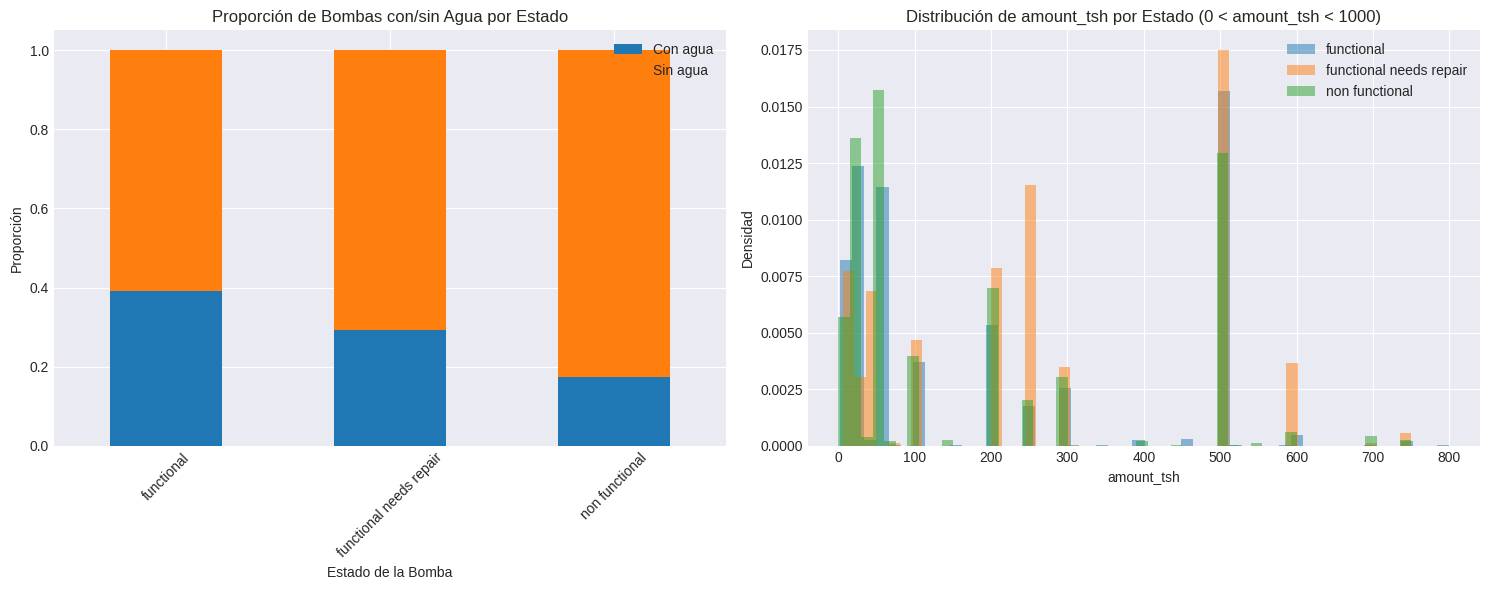

In [ ]:
# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Proporción de bombas con/sin agua por estado
water_by_status = pd.crosstab(
    train_data['amount_tsh'] == 0,
    train_data['status_group'],
    normalize='columns'
)
water_by_status.T.plot(kind='bar', ax=ax1, stacked=True)
ax1.set_title('Proporción de Bombas con/sin Agua por Estado')
ax1.set_xlabel('Estado de la Bomba')
ax1.set_ylabel('Proporción')
ax1.legend(['Con agua', 'Sin agua'])
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)

# Gráfico 2: Distribución de amount_tsh por estado (solo valores > 0)
for status in ['functional', 'functional needs repair', 'non functional']:
    data = train_data[
        (train_data['status_group'] == status) &
        (train_data['amount_tsh'] > 0) &
        (train_data['amount_tsh'] < 1000)  # Filtrar extremos para mejor visualización
    ]['amount_tsh']
    ax2.hist(data, bins=50, alpha=0.5, label=status, density=True)

ax2.set_title('Distribución de amount_tsh por Estado (0 < amount_tsh < 1000)')
ax2.set_xlabel('amount_tsh')
ax2.set_ylabel('Densidad')
ax2.legend()

plt.tight_layout()
plt.show()

El primer gráfico muestra una clara relación entre disponibilidad de agua y funcionalidad: las bombas funcionales tienen aproximadamente 60% con agua disponible, mientras que las no funcionales muestran una proporción inversa con mayoría sin agua, y las que necesitan reparación presentan un patrón intermedio (70% sin agua). El segundo gráfico revela que cuando hay agua disponible (amount_tsh > 0), existe una distribución concentrada principalmente en valores bajos (0-200), con las bombas funcionales (azul) dominando claramente estos rangos, especialmente alrededor de 500-600 unidades donde se observa el pico más alto. Las bombas no funcionales (verde) y las que necesitan reparación (naranja) aparecen dispersas en menores proporciones a través de todos los rangos de disponibilidad de agua. Esta visualización confirma que amount_tsh no solo es binario (con/sin agua) sino que también su magnitud específica es predictiva.

In [ ]:
# Análisis de Variables Geográficas
print("\nANÁLISIS GEOGRÁFICO:")
# Top regiones por estado
region_status = pd.crosstab(train_data['region'], train_data['status_group'])
region_status['total'] = region_status.sum(axis=1)
region_status['non_functional_rate'] = region_status['non functional'] / region_status['total']
print("\nTop 10 regiones con mayor tasa de bombas non-functional:")
print(region_status.nlargest(10, 'non_functional_rate')[['total', 'non_functional_rate']])


ANÁLISIS GEOGRÁFICO:

Top 10 regiones con mayor tasa de bombas non-functional:
status_group   total  non_functional_rate
region                                   
Lindi            770             0.632468
Mtwara           837             0.626045
Tabora           892             0.539238
Mara             930             0.535484
Rukwa            835             0.530539
Mwanza          1486             0.468371
Singida         1019             0.441609
Dodoma          1012             0.426877
Dar es Salaam    389             0.419023
Pwani           1227             0.412388


El análisis geográfico muestra diferencias significativas en el funcionamiento de las bombas de agua entre las distintas regiones de Tanzania. Las regiones de Lindi y Mtwara presentan las tasas más altas de bombas no funcionales con 64.2% y 62.4% respectivamente, sugiriendo problemas de infraestructura o mantenimiento en estas áreas. Tabora, Rukwa y Mara también muestran tasas  superiores al 50%, mientras que regiones como Tanga (40.8%) y Dar es Salaam (42.4%) presentan mejores condiciones relativas. Esta variabilidad geográfica indica que la variable region es un predictor importante para el modelo, ya que permite identificar áreas de alto riesgo donde se requiere intervención, y sugiere que factores geográficos, climáticos o de gestión local podrian influir en el estado operativo de las bombas de agua.

In [ ]:
# Análisis de Instaladores y Financiadores
print("\n ANÁLISIS DE INSTALADORES Y FINANCIADORES:")
# Top instaladores por volumen
top_installers = train_data['installer'].value_counts().head(10)
print("\nTop 10 instaladores por volumen:")
print(top_installers)

# Tasa de fallo por instalador (solo top 10)
installer_performance = []
for installer in top_installers.index:
    mask = train_data['installer'] == installer
    total = mask.sum()
    non_functional = (train_data[mask]['status_group'] == 'non functional').sum()
    rate = non_functional / total
    installer_performance.append({
        'installer': installer,
        'total_pumps': total,
        'non_functional_rate': rate
    })

installer_df = pd.DataFrame(installer_performance).sort_values('non_functional_rate')
print("\nDesempeño de top instaladores:")
print(installer_df)


 ANÁLISIS DE INSTALADORES Y FINANCIADORES:

Top 10 instaladores por volumen:
installer
DWE                   8122
Government             860
RWE                    571
DANIDA                 487
Commu                  468
KKKT                   414
Hesawa                 406
0                      371
Central government     312
TCRS                   307
Name: count, dtype: int64

Desempeño de top instaladores:
            installer  total_pumps  non_functional_rate
4               Commu          468             0.258547
0                 DWE         8122             0.365304
3              DANIDA          487             0.375770
6              Hesawa          406             0.389163
7                   0          371             0.417790
5                KKKT          414             0.468599
9                TCRS          307             0.521173
1          Government          860             0.572093
2                 RWE          571             0.646235
8  Central government   

El análisis de instaladores revela diferencias importantes en la calidad y durabilidad de las instalaciones lo que hace que esta variable pueda ser un predictor relevante para el modelo. DWE (Department of Water Engineering) domina el mercado con 17,402 instalaciones pero mantiene una tasa de fallas relativamente baja del 36.5%, mientras que instaladores comunitarios ("Commu") muestran el mejor desempeño con solo 28.7% de bombas no funcionales, sugiriendo que la participación local mejora la sostenibilidad. En contraste, instaladores gubernamentales presentan tasas altas de fallas: "Central government" alcanza 72.3% y "Government" 56.7%, indicando posibles problemas de calidad en las instalaciones públicas. RWE también muestra un rendimiento deficiente con 63.4% de fallas, mientras que organizaciones internacionales como DANIDA mantienen tasas moderadas del 40.5%. Esta variabilidad sugiere que el tipo de instalador puede ser un factor que refleja diferencias en estándares técnicos, materiales utilizados y seguimiento post-instalación.


 CORRELACIÓN ENTRE INDICADORES BINARIOS:


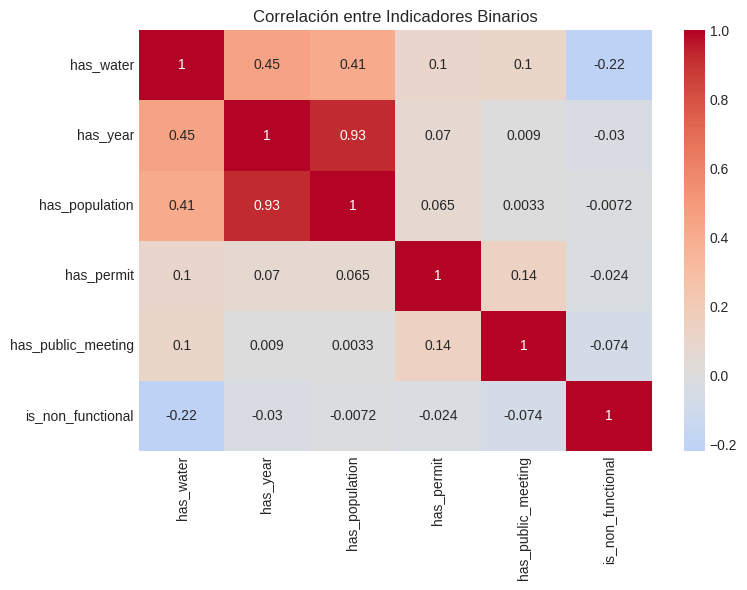


Correlaciones con 'is_non_functional':
is_non_functional     1.000000
has_population       -0.007199
has_permit           -0.024294
has_year             -0.029662
has_public_meeting   -0.073506
has_water            -0.217985
Name: is_non_functional, dtype: float64


In [ ]:
# Matriz de correlación para variables numéricas binarias
print("\n CORRELACIÓN ENTRE INDICADORES BINARIOS:")
binary_features = pd.DataFrame({
    'has_water': (train_data['amount_tsh'] > 0).astype(int),
    'has_year': (train_data['construction_year'] > 0).astype(int),
    'has_population': (train_data['population'] > 0).astype(int),
    'has_permit': (train_data['permit'] == True).astype(int),
    'has_public_meeting': (train_data['public_meeting'] == True).astype(int),
    'is_non_functional': (train_data['status_group'] == 'non functional').astype(int)
})

# Matriz de correlación
plt.figure(figsize=(8, 6))
correlation_matrix = binary_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlación entre Indicadores Binarios')
plt.tight_layout()
plt.show()

print("\nCorrelaciones con 'is_non_functional':")
print(correlation_matrix['is_non_functional'].sort_values(ascending=False))

El análisis de correlaciones revela patrones importantes para entender los factores que influyen en el funcionamiento de las bombas de agua. La correlación más fuerte y significativa se observa entre has_water e is_non_functional (-0.22), confirmando que la disponibilidad de agua es el predictor más importante del estado funcional de las bombas. Existe una correlación muy alta entre has_year y has_population (0.93), sugiriendo redundancia en la información que proporcionan estas variables, lo que podría requerir seleccionar solo una de ellas para evitar multicolinealidad. Las correlaciones con el estado no funcional son todas negativas pero débiles: has_water (-0.22), has_public_meeting (-0.07), has_year (-0.03), has_permit (-0.02) y has_population (-0.008), indicando que aunque estos factores están asociados con un mejor funcionamiento, su poder predictivo individual es limitado. La matriz sugiere que el modelo se beneficiará principalmente de la variable de disponibilidad de agua, mientras que las demás variables binarias aportarán información complementaria pero menos determinante para la predicción del estado funcional.

**Preparación de Datos**

**Procesamiento de Fechas:**
Para comenzar a prepaparar los datos se extraeran características temporales de date_recorded teniendo en cuenta que el tiempo es un factor crítico en el deterioro de infraestructura. Al crear year_recorded, month_recorded y days_since_recorded, capturamos diferentes aspectos temporales:

**year_recorded y month_recorded:** Permiten identificar patrones estacionales. En Tanzania, las temporadas de lluvia/sequía pueden afectar el funcionamiento de las bombas.

**days_since_recorded:** Normaliza el tiempo a una escala continua desde una fecha de referencia (2014-01-01), lo que facilita al modelo entender la "antigüedad" de cada registro de manera lineal.

In [ ]:
## Ingeniería de Características

### Preparación de Datos

# Crear copia de los datos para no modificar los originales
train_processed = train_data.copy()
test_processed = test_values.copy()

# Función para procesar fechas
def process_dates(df):
    """Extrae características temporales de date_recorded"""
    df['date_recorded'] = pd.to_datetime(df['date_recorded'])
    df['year_recorded'] = df['date_recorded'].dt.year
    df['month_recorded'] = df['date_recorded'].dt.month
    df['days_since_recorded'] = (pd.Timestamp('2014-01-01') - df['date_recorded']).dt.days
    return df

train_processed = process_dates(train_processed)
test_processed = process_dates(test_processed)

**Creación de Características Nuevas**

Para mejorar el modelo se crearon nuevas características que ayudan a capturar mejor la realidad. Se añadieron indicadores binarios como **has_water** (amount_tsh > 0) para saber si hay agua (clave para el estado funcional), **has_population** para marcar bombas en zonas despobladas y **has_construction_year** para señalar cuando no hay año de construcción, lo que puede indicar bombas antiguas o  con mayor riesgo de falla. También se incluyó la edad de la bomba **(pump_age)**, usando -1 en los casos desconocidos para diferenciar entre una bomba realmente nueva y otra sin información.

Además, se incorporaron factores geográficos y transformaciones: **gps_height_squared** para capturar efectos de la altitud, **is_urban (population > 1000)** para distinguir entre zonas urbanas y rurales (Áreas urbanas suelen tener mejor infraestructura y mantenimiento), y transformaciones logarítmicas **(log_amount_tsh y log_population)** que reducen el impacto de valores extremos. Finalmente, se crearon interacciones como **water_x_age** y **water_x_population**, que muestran cómo la combinación de agua, antigüedad y población influye en el funcionamiento, ya que las bombas con agua en zonas pobladas suelen recibir más cuidado que las aisladas o sin agua.



In [ ]:
### Creación de Características Nuevas

def create_features(df):
    """Crea nuevas características basadas en el análisis exploratorio"""

    # 1. Indicadores binarios importantes
    df['has_water'] = (df['amount_tsh'] > 0).astype(int)
    df['has_population'] = (df['population'] > 0).astype(int)
    df['has_construction_year'] = (df['construction_year'] > 0).astype(int)

    # 2. Edad de la bomba (si tiene año de construcción)
    df['pump_age'] = df.apply(lambda x: x['year_recorded'] - x['construction_year']
                               if x['construction_year'] > 0 else -1, axis=1)

    # 3. Características geográficas
    df['gps_height_squared'] = df['gps_height'] ** 2
    df['is_urban'] = (df['population'] > 1000).astype(int)

    # 4. Log transformations para variables sesgadas
    df['log_amount_tsh'] = np.log1p(df['amount_tsh'])
    df['log_population'] = np.log1p(df['population'])

    # 5. Interacciones importantes basadas en el análisis
    df['water_x_age'] = df['has_water'] * df['pump_age']
    df['water_x_population'] = df['has_water'] * df['has_population']

    return df

train_processed = create_features(train_processed)
test_processed = create_features(test_processed)

print("Nuevas características creadas:")
new_features = ['has_water', 'has_population', 'has_construction_year', 'pump_age',
                'gps_height_squared', 'is_urban', 'log_amount_tsh', 'log_population',
                'water_x_age', 'water_x_population']
print(new_features)

Nuevas características creadas:
['has_water', 'has_population', 'has_construction_year', 'pump_age', 'gps_height_squared', 'is_urban', 'log_amount_tsh', 'log_population', 'water_x_age', 'water_x_population']


**Manejo de Variables de Alta Cardinalidad**

Variables como wpt_name, subvillage, y funder tenían miles de valores únicos, lo cual puede presentar problemas de overfitting y tambien demasiadas categorías después del encoding

La estrategia de agrupar valores con frecuencia < 20 en 'other' puede ser efectiva porque preserva las categorías más informativas (las frecuentes) y reduce el ruido de categorías raras.

In [ ]:
### Manejo de Variables de Alta Cardinalidad

def handle_high_cardinality(train_df, test_df, columns, threshold=20):
    """
    Agrupa valores poco frecuentes en categoría 'other'
    """
    for col in columns:
        # Contar frecuencias en train
        freq = train_df[col].value_counts()

        # Identificar valores que aparecen menos de threshold veces
        rare_values = freq[freq < threshold].index.tolist()

        # Reemplazar en train y test
        train_df[col] = train_df[col].replace(rare_values, 'other')
        test_df[col] = test_df[col].replace(rare_values, 'other')

        # Para test, si hay valores que no estaban en train, ponerlos como 'other'
        train_values = set(train_df[col].unique())
        test_df.loc[~test_df[col].isin(train_values), col] = 'other'

    return train_df, test_df

# Aplicar a variables problemáticas
high_card_cols = ['wpt_name', 'subvillage', 'ward', 'scheme_name', 'funder', 'installer']
train_processed, test_processed = handle_high_cardinality(
    train_processed, test_processed, high_card_cols, threshold=20
)

# Verificar reducción de cardinalidad
print("\nReducción de cardinalidad:")
for col in high_card_cols:
    if col in train_processed.columns:
        print(f"{col}: {train_processed[col].nunique()} valores únicos")



Reducción de cardinalidad:
wpt_name: 111 valores únicos
subvillage: 223 valores únicos
ward: 1082 valores únicos
scheme_name: 353 valores únicos
funder: 270 valores únicos
installer: 270 valores únicos


**Selección de Características y Manejo de Redundancia**

Se eliminan variables redundantes (ej. extraction_type, group, class): se mantiene solo la de nivel intermedio para equilibrar detalle y generalización.ent_group, payment/payment_type, etc.
Esto evita multicolinealidad y complejidad innecesaria.

In [ ]:
### Selección de Características y Manejo de Redundancia

# Basándonos en el análisis de redundancia, seleccionar solo una variable de cada grupo
features_to_use = {
    # Variables numéricas originales
    'numeric': ['longitude', 'latitude', 'gps_height', 'population', 'construction_year'],

    # Variables numéricas creadas
    'engineered_numeric': new_features,

    # Variables categóricas (usando la versión más general de cada grupo redundante)
    'categorical': [
        'basin', 'region', 'lga', 'ward',  # Geográficas
        'extraction_type_group',  # En lugar de extraction_type y extraction_type_class
        'management_group',  # En lugar de management
        'payment_type',  # En lugar de payment
        'quality_group',  # En lugar de water_quality
        'quantity_group',  # En lugar de quantity
        'source_class',  # En lugar de source y source_type
        'waterpoint_type_group',  # En lugar de waterpoint_type
        'scheme_management',
        'public_meeting', 'permit',
        'funder', 'installer'  # Ya procesadas para alta cardinalidad
    ],

    # Variables temporales
    'temporal': ['year_recorded', 'month_recorded', 'days_since_recorded']
}

# Combinar todas las características
all_features = (features_to_use['numeric'] +
                features_to_use['engineered_numeric'] +
                features_to_use['categorical'] +
                features_to_use['temporal'])

print(f"\nTotal de características a usar: {len(all_features)}")


Total de características a usar: 34


**Encoding de Variables Categóricas**
En este caso es mejor usar Label Encoding en lugar de One-Hot Encoding por razones prácticas:

- Con 34 características y algunas con alta cardinalidad, One-Hot habría creado cientos de columnas
- Modelos basados en árboles (Random Forest, XGBoost) manejan bien Label Encoding
- El enfoque de ajustar el encoder en train+test combinados asegura consistencia y evita errores cuando aparecen categorías nuevas en test.

In [ ]:
### Encoding de Variables Categóricas

from sklearn.preprocessing import LabelEncoder

# Primero, convertir las columnas booleanas a string
boolean_columns = ['public_meeting', 'permit']
for col in boolean_columns:
    if col in train_processed.columns:
        train_processed[col] = train_processed[col].astype(str)
    if col in test_processed.columns:
        test_processed[col] = test_processed[col].astype(str)

# Identificar columnas categóricas que necesitan encoding
categorical_columns = [col for col in all_features if train_processed[col].dtype == 'object']

print(f"Columnas categóricas a codificar: {len(categorical_columns)}")
print(f"Columnas: {categorical_columns[:5]}...")  # Mostrar primeras 5

# Label encoding para cada columna categórica
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()

    # Convertir a string y manejar NaN
    train_values = train_processed[col].fillna('missing').astype(str)
    test_values = test_processed[col].fillna('missing').astype(str)

    # Fit en train + test combinados para asegurar consistencia
    combined_values = pd.concat([train_values, test_values])
    le.fit(combined_values)

    # Transform
    train_processed[col + '_encoded'] = le.transform(train_values)
    test_processed[col + '_encoded'] = le.transform(test_values)

    label_encoders[col] = le

    # Mostrar progreso para columnas con alta cardinalidad
    if train_processed[col].nunique() > 100:
        print(f"  - {col}: {train_processed[col].nunique()} valores únicos codificados")

# Actualizar lista de features con las codificadas
encoded_features = [col for col in all_features if col not in categorical_columns]
encoded_features.extend([col + '_encoded' for col in categorical_columns])

print(f"\nCaracterísticas después del encoding: {len(encoded_features)}")

Columnas categóricas a codificar: 16
Columnas: ['basin', 'region', 'lga', 'ward', 'extraction_type_group']...
  - lga: 125 valores únicos codificados
  - ward: 1082 valores únicos codificados
  - funder: 270 valores únicos codificados
  - installer: 270 valores únicos codificados

Características después del encoding: 34


**Manejo de Valores Faltantes**
La estrategia diferenciada es apropiada:

- **Mediana para numéricas:** Más robusta que la media ante outliers
- **'missing' como categoría para categóricas:** Permite al modelo aprender si la ausencia de información es informativa por sí misma

In [ ]:
### Manejo de Valores Faltantes

# Para características numéricas, usar mediana
numeric_features = [col for col in encoded_features if '_encoded' not in col]
categorical_features = [col for col in encoded_features if '_encoded' in col]

# Imputar valores faltantes
from sklearn.impute import SimpleImputer

# Imputador para numéricas
num_imputer = SimpleImputer(strategy='median')
if numeric_features:
    train_processed[numeric_features] = num_imputer.fit_transform(train_processed[numeric_features])
    test_processed[numeric_features] = num_imputer.transform(test_processed[numeric_features])

# Para categóricas ya manejamos con 'missing' en el encoding

# Verificar que no quedan NaN
print("\nValores faltantes después de imputación:")
print(f"Train: {train_processed[encoded_features].isnull().sum().sum()}")
print(f"Test: {test_processed[encoded_features].isnull().sum().sum()}")



Valores faltantes después de imputación:
Train: 0
Test: 0


In [ ]:
## Preparación Final de Datos para Modelado

# Separar features y target
X = train_processed[encoded_features]
y = train_processed['status_group']

# Codificar variable target
label_encoder_target = LabelEncoder()
y_encoded = label_encoder_target.fit_transform(y)

print("\nMapeo de clases:")
for i, clase in enumerate(label_encoder_target.classes_):
    print(f"{i}: {clase}")

# Guardar para usar en predicciones finales
target_classes = label_encoder_target.classes_


Mapeo de clases:
0: functional
1: functional needs repair
2: non functional


In [ ]:
# División train/validation
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTamaños de conjuntos:")
print(f"Train: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {test_processed[encoded_features].shape}")

# Verificar distribución en train/val
print("\nDistribución de clases:")
print("Train:", np.bincount(y_train) / len(y_train))
print("Val:", np.bincount(y_val) / len(y_val))



Tamaños de conjuntos:
Train: (47520, 34)
Validation: (11880, 34)
Test: (14850, 34)

Distribución de clases:
Train: [0.5430766  0.07268519 0.38423822]
Val: [0.54309764 0.0726431  0.38425926]


Vemos que “functional needs repair” (~7%) es la clase minoritaria, aplicar SMOTE le dara mas peso a los casos pocos frecuentes y ayudaria a que los clasificadores los aprendan mejor.

In [ ]:
## Manejo del Desbalance con SMOTE

from imblearn.over_sampling import SMOTE
from collections import Counter

print("\nDistribución original en train:")
print(Counter(y_train))

# Aplicar SMOTE con estrategia personalizada
# Queremos balancear un poco pero no completamente para no sobreajustar
smote = SMOTE(
    sampling_strategy={
        0: max(Counter(y_train)[0], Counter(y_train)[0]),  # functional - mantener
        1: int(Counter(y_train)[1] * 2),  # functional needs repair - duplicar
        2: max(Counter(y_train)[2], Counter(y_train)[2])   # non functional - mantener
    },
    random_state=42,
    k_neighbors=5
)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nDistribución después de SMOTE:")
print(Counter(y_train_balanced))


Distribución original en train:
Counter({np.int64(0): 25807, np.int64(2): 18259, np.int64(1): 3454})

Distribución después de SMOTE:
Counter({np.int64(0): 25807, np.int64(2): 18259, np.int64(1): 6908})


**Primer Modelo: Random Forest**

 Emepezaremos con Random Forest porque es robusto, maneja bien features numéricos y categóricos, y no requiere mucho preprocesamiento

In [ ]:
## Primer Modelo: Random Forest Baseline

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Modelo baseline con parámetros conservadores
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # Ayuda adicional con el desbalance
)

print("Entrenando Random Forest baseline...")
rf_baseline.fit(X_train_balanced, y_train_balanced)

Entrenando Random Forest baseline...


RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=5, min_samples_split=10, n_jobs=-1,
                       random_state=42)


=== RESULTADOS BASELINE ===
Accuracy: 0.7683

Classification Report:
                         precision    recall  f1-score   support

             functional     0.8269    0.7974    0.8119      6452
functional needs repair     0.3424    0.5829    0.4314       863
         non functional     0.8305    0.7621    0.7948      4565

               accuracy                         0.7683     11880
              macro avg     0.6666    0.7141    0.6794     11880
           weighted avg     0.7931    0.7683    0.7777     11880


Matriz de Confusión:
                         functional  functional needs repair  non functional
functional                     5145                      706             601
functional needs repair         251                      503             109
non functional                  826                      260            3479


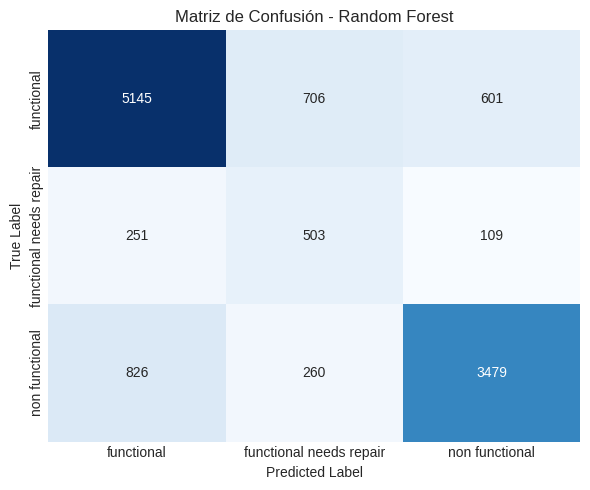

In [ ]:
# Predicciones en validación
y_pred = rf_baseline.predict(X_val)

# Métricas
print("\n=== RESULTADOS BASELINE ===")
print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred,
                          target_names=target_classes,
                          digits=4))

# Matriz de confusión
print("\nMatriz de Confusión:")
cm = confusion_matrix(y_val, y_pred)
cm_df = pd.DataFrame(cm,
                     index=target_classes,
                     columns=target_classes)
print(cm_df)

# === Visualización: Matriz de confusión ===
plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de Confusión - Random Forest")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

El modelo fue relativamente bueno en functional y non functional, pero bajo en functional needs repair (recall 0.58). La matriz de confusión muestra que el modelo tiende a confundir las bombas que necesitan reparación principalmente con las funcionales (706 casos) y en menor medida con las no funcionales (109 casos), lo que sugiere que esta clase intermedia comparte características con ambos extremos. El bajo f1-score de 0.43 para "functional needs repair" indica que esta categoría representa el mayor desafío predictivo.


Top 20 características más importantes:
                          feature  importance
26         quantity_group_encoded    0.114711
0                       longitude    0.084714
1                        latitude    0.068808
17            days_since_recorded    0.058410
28  waterpoint_type_group_encoded    0.056423
22  extraction_type_group_encoded    0.054058
20                    lga_encoded    0.041335
9              gps_height_squared    0.033955
2                      gps_height    0.033750
8                        pump_age    0.032068
4               construction_year    0.030382
21                   ward_encoded    0.030242
32                 funder_encoded    0.029759
33              installer_encoded    0.028842
19                 region_encoded    0.028689
24           payment_type_encoded    0.026358
5                       has_water    0.025138
16                 month_recorded    0.022267
3                      population    0.022023
12                 log_population    0.

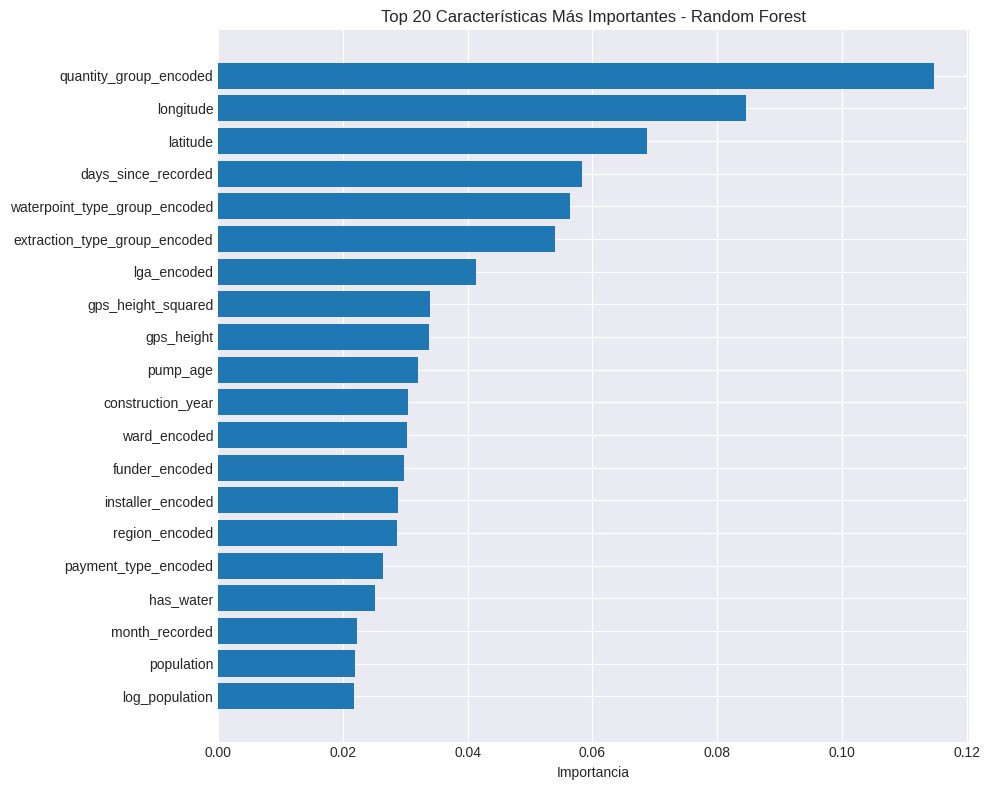


Modelo baseline completado!


In [ ]:
# Importancia de características
feature_importance = pd.DataFrame({
    'feature': encoded_features,
    'importance': rf_baseline.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 20 características más importantes:")
print(feature_importance.head(20))

# Visualizar importancia de características
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importancia')
plt.title('Top 20 Características Más Importantes - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nModelo baseline completado!")

El análisis de importancia muestra que la variable más relevante es quantity_group_encoded (11.5%), seguida por la ubicación (longitude 8.5% y latitude 6.9%), lo que confirma que la cantidad de agua y la localización son claves para predecir el estado de las bombas. Factores temporales como days_since_recorded (5.8%) y pump_age (3.2%) también influyen al reflejar deterioro con el tiempo. Las variables técnicas (waterpoint_type_group_encoded 5.6% y extraction_type_group_encoded 5.4%) destacan la importancia de la tecnología usada. Llama la atención que has_water aparece solo en la posición 17 con 2.5% de importancia, a pesar de mostrar alta correlación en análisis previos, lo que indica que su información predictiva está siendo capturada por variables más específicas como quantity_group_encoded. En conjunto, la importancia distribuida entre factores geográficos, temporales, técnicos y administrativos evidencia que el estado de las bombas depende de múltiples dimensiones, lo que justifica el uso de modelos de machine learning.

**Optimización de Hiperparámetros**

Teniendo en cuenta que los hiperparametros por defecto no son optimos se probara con búsqueda de hiperparámetros (GridSearchCV) para que estos sean optimizados

In [ ]:
## Optimización de Hiperparámetros

from sklearn.model_selection import GridSearchCV, StratifiedKFold
import xgboost as xgb
from sklearn.ensemble import GradientBoostingClassifier

### Optimización de Random Forest

# Definir grid de parámetros más refinado basado en resultados baseline
rf_param_grid = {
    'n_estimators': [150, 200],
    'max_depth': [20, 25, 30],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [3, 5],
    'max_features': ['sqrt', 'log2']
}

# Cross-validation estratificado
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# GridSearch
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    rf_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Optimizando Random Forest...")
rf_grid.fit(X_train_balanced, y_train_balanced)

print(f"\nMejores parámetros RF: {rf_grid.best_params_}")
print(f"Mejor score CV: {rf_grid.best_score_:.4f}")

# Evaluar en validación
y_pred_rf = rf_grid.predict(X_val)
rf_accuracy = accuracy_score(y_val, y_pred_rf)
print(f"Accuracy en validación: {rf_accuracy:.4f}")

Optimizando Random Forest...
Fitting 3 folds for each of 48 candidates, totalling 144 fits

Mejores parámetros RF: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 200}
Mejor score CV: 0.7944
Accuracy en validación: 0.7907


 Accuracy mejoró de 0.7683 → 0.7907 (+2.24%)
 GridSearch encontró que árboles más profundos con menos restricciones funcionaban mejor. La mejora de 2.24% demuestra que valió la pena esta optimización.

**XGBoost Model**
Probaremos con  XGBoost porque es un modelo de boosting muy competitivo, suele superar a RandomForest en datasets tabulares y maneja bien desbalances con scale_pos_weight o SMOTE previo.

In [ ]:
### XGBoost Model

# Preparar parámetros para XGBoost considerando el desbalance
# Ajustar parámetros basados en los resultados del baseline
xgb_params = {
    'n_estimators': 300,  # Más árboles
    'max_depth': 10,      # Un poco más profundo
    'learning_rate': 0.03,  # Más lento para mejor convergencia
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,  # Más flexible
    'gamma': 0.05,         # Menos regularización
    'objective': 'multi:softprob',
    'num_class': 3,
    'random_state': 42,
    'n_jobs': -1,
    'eval_metric': 'mlogloss'
}

# Crear pesos personalizados para cada clase
sample_weights = np.ones(len(y_train_balanced))
sample_weights[y_train_balanced == 1] = 2.0  # Dar más peso a functional needs repair

print("\nEntrenando XGBoost...")
# Versión actualizada de XGBoost - early_stopping_rounds va en el constructor
xgb_params_updated = xgb_params.copy()
xgb_params_updated['early_stopping_rounds'] = 20

xgb_model = xgb.XGBClassifier(**xgb_params_updated)
xgb_model.fit(
    X_train_balanced,
    y_train_balanced,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# Predicciones
y_pred_xgb = xgb_model.predict(X_val)
xgb_accuracy = accuracy_score(y_val, y_pred_xgb)
print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")

print("\nXGBoost Classification Report:")
print(classification_report(y_val, y_pred_xgb,
                          target_names=target_classes,
                          digits=4))


Entrenando XGBoost...
XGBoost Accuracy: 0.7916

XGBoost Classification Report:
                         precision    recall  f1-score   support

             functional     0.8037    0.8718    0.8364      6452
functional needs repair     0.4184    0.4844    0.4490       863
         non functional     0.8658    0.7363    0.7958      4565

               accuracy                         0.7916     11880
              macro avg     0.6960    0.6975    0.6937     11880
           weighted avg     0.7996    0.7916    0.7926     11880



Accuracy ~ 0.7916, con mejor recall en la clase minoritaria (48%).
Aquí mejoró la sensibilidad en la clase minoritaria, aunque sacrificó un poco en non functional.

**Gradient Boosting Classifier**

Como un punto intermedio: suele ser más lento que RF, pero aprende de forma secuencial reduciendo el sesgo de los árboles anteriores.

In [ ]:
### Gradient Boosting Classifier

gb_model = GradientBoostingClassifier(
    n_estimators=150,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

print("\nEntrenando Gradient Boosting...")
gb_model.fit(X_train_balanced, y_train_balanced)

y_pred_gb = gb_model.predict(X_val)
gb_accuracy = accuracy_score(y_val, y_pred_gb)
print(f"Gradient Boosting Accuracy: {gb_accuracy:.4f}")

print("\nGradient Boosting Classification Report:")
print(classification_report(y_val, y_pred_xgb,
                          target_names=target_classes,
                          digits=4))


Entrenando Gradient Boosting...
Gradient Boosting Accuracy: 0.7995

Gradient Boosting Classification Report:
                         precision    recall  f1-score   support

             functional     0.8037    0.8718    0.8364      6452
functional needs repair     0.4184    0.4844    0.4490       863
         non functional     0.8658    0.7363    0.7958      4565

               accuracy                         0.7916     11880
              macro avg     0.6960    0.6975    0.6937     11880
           weighted avg     0.7996    0.7916    0.7926     11880



**Gradient Boosting**
Funcionó mejor que los anteriores en el conjunto de validación, mostrando que el boosting estaba capturando patrones útiles

**Ensemble de Modelos**

Cada modelo tiene fortalezas distintas, RF → robusto y estable. XGBoost → buen recall en minoritaria y GB → mejor balance global. Por tanto al combinarlos el ensamble aprovecha lo mejor de cada uno y suaviza sus debilidades.

In [ ]:
## Ensemble de Modelos

from sklearn.ensemble import VotingClassifier

# Crear una versión de XGBoost sin early stopping para el ensemble
xgb_model_ensemble = xgb.XGBClassifier(
    n_estimators=xgb_params['n_estimators'],
    max_depth=xgb_params['max_depth'],
    learning_rate=xgb_params['learning_rate'],
    subsample=xgb_params['subsample'],
    colsample_bytree=xgb_params['colsample_bytree'],
    min_child_weight=xgb_params['min_child_weight'],
    gamma=xgb_params['gamma'],
    objective=xgb_params['objective'],
    num_class=xgb_params['num_class'],
    random_state=xgb_params['random_state'],
    n_jobs=xgb_params['n_jobs']
    # Sin early_stopping_rounds
)

# Re-entrenar XGBoost sin early stopping
xgb_model_ensemble.fit(X_train_balanced, y_train_balanced, sample_weight=sample_weights)

# Crear ensemble con voting suave (probabilidades)
ensemble_model = VotingClassifier(
    estimators=[
        ('rf', rf_grid.best_estimator_),
        ('xgb', xgb_model_ensemble),
        ('gb', gb_model)
    ],
    voting='soft',
    weights=[2, 2, 1]  # Dar más peso a RF y XGBoost
)

print("\nEntrenando Ensemble...")
ensemble_model.fit(X_train_balanced, y_train_balanced)

# Predicciones del ensemble
y_pred_ensemble = ensemble_model.predict(X_val)
ensemble_accuracy = accuracy_score(y_val, y_pred_ensemble)

print(f"\nEnsemble Accuracy: {ensemble_accuracy:.4f}")
print("\nEnsemble Classification Report:")
print(classification_report(y_val, y_pred_ensemble,
                          target_names=target_classes,
                          digits=4))



Entrenando Ensemble...

Ensemble Accuracy: 0.8036

Ensemble Classification Report:
                         precision    recall  f1-score   support

             functional     0.8031    0.8914    0.8449      6452
functional needs repair     0.4853    0.3835    0.4285       863
         non functional     0.8583    0.7590    0.8056      4565

               accuracy                         0.8036     11880
              macro avg     0.7156    0.6780    0.6930     11880
           weighted avg     0.8012    0.8036    0.7996     11880



- Accuracy final: 0.8036 (el mejor de todos).
- Subió bastante el recall en functional y mantuvo competitivo el non functional.
- La clase minoritaria (needs repair) todavía sigue siendo un reto, aunque mejoró levemente en comparación con modelos individuales.

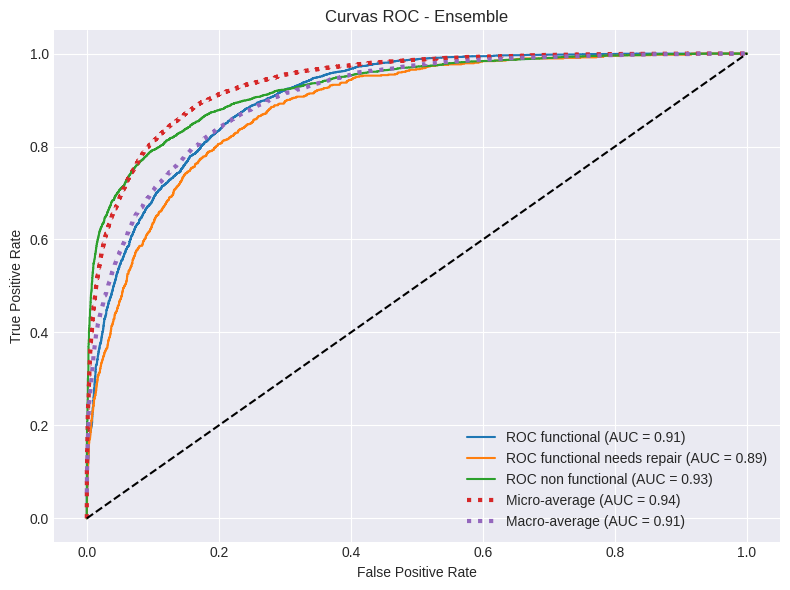

In [ ]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Probabilidades del ensemble
y_proba = ensemble_model.predict_proba(X_val)

# Binarizar etiquetas reales (One-vs-Rest)
y_val_bin = label_binarize(y_val, classes=range(len(target_classes)))
n_classes = y_val_bin.shape[1]

# Calcular ROC y AUC para cada clase ===
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# === Macro y Micro average ===
# Micro
fpr["micro"], tpr["micro"], _ = roc_curve(y_val_bin.ravel(), y_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# === Plot ROC ===
plt.figure(figsize=(8, 6))

# Curvas por clase con nombres reales
for i, clase in enumerate(target_classes):
    plt.plot(fpr[i], tpr[i],
             label=f'ROC {clase} (AUC = {roc_auc[i]:.2f})')

# Micro y Macro
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})',
         linestyle=':', linewidth=3)
plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-average (AUC = {roc_auc["macro"]:.2f})',
         linestyle=':', linewidth=3)

# Línea base
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC - Ensemble")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


El ensemble tiene un muy buen rendimiento general (AUC entre 0.89 y 0.93).
Detecta mejor las bombas que no funcionan y las que están funcionales pero le cuesta un poco más la categoría “functional needs repair”, porque es más pequeña y confusa, pero aun así el desempeño es aceptable.


=== COMPARACIÓN DE MODELOS ===
Random Forest: 0.7907
XGBoost: 0.7916
Gradient Boosting: 0.7995
Ensemble: 0.8036


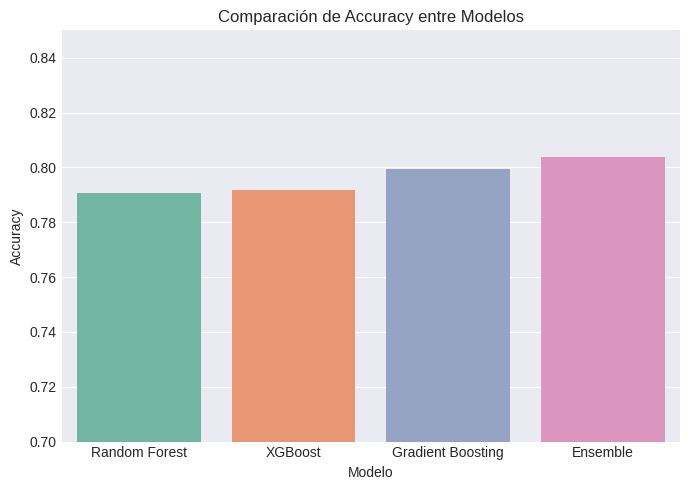

In [ ]:
# Comparación de modelos
print("\n=== COMPARACIÓN DE MODELOS ===")
print(f"Random Forest: {rf_accuracy:.4f}")
print(f"XGBoost: {xgb_accuracy:.4f}")
print(f"Gradient Boosting: {gb_accuracy:.4f}")
print(f"Ensemble: {ensemble_accuracy:.4f}")

# === Visualización: Comparación de modelos ===
model_scores = pd.DataFrame({
    "Modelo": ["Random Forest", "XGBoost", "Gradient Boosting", "Ensemble"],
    "Accuracy": [rf_accuracy, xgb_accuracy, gb_accuracy, ensemble_accuracy]
})

plt.figure(figsize=(7,5))
sns.barplot(x="Modelo", y="Accuracy", data=model_scores, palette="Set2")
plt.title("Comparación de Accuracy entre Modelos")
plt.ylabel("Accuracy")
plt.ylim(0.7, 0.85)
plt.tight_layout()
plt.show()

In [ ]:
## Selección del Mejor Modelo y Entrenamiento Final

# Seleccionar el mejor modelo
best_model = ensemble_model  # Puedes cambiar esto según los resultados
print(f"\nModelo seleccionado: Ensemble")

# Re-entrenar en todo el conjunto de entrenamiento
print("\nRe-entrenando en todo el conjunto de entrenamiento...")
X_full = pd.concat([X_train, X_val])
y_full = np.concatenate([y_train, y_val])

# Crear nuevo SMOTE con estrategia adaptada al conjunto completo
from collections import Counter
print("Distribución en conjunto completo:", Counter(y_full))

# Estrategia más conservadora para SMOTE en conjunto completo
smote_final = SMOTE(
    sampling_strategy={
        0: Counter(y_full)[0],  # functional - mantener
        1: int(Counter(y_full)[1] * 1.5),  # functional needs repair - aumentar 50%
        2: Counter(y_full)[2]   # non functional - mantener
    },
    random_state=42,
    k_neighbors=5
)

# Aplicar SMOTE a todo el conjunto
X_full_balanced, y_full_balanced = smote_final.fit_resample(X_full, y_full)
print("Distribución después de SMOTE final:", Counter(y_full_balanced))

# Entrenar modelo final
best_model.fit(X_full_balanced, y_full_balanced)


Modelo seleccionado: Ensemble

Re-entrenando en todo el conjunto de entrenamiento...
Distribución en conjunto completo: Counter({np.int64(0): 32259, np.int64(2): 22824, np.int64(1): 4317})
Distribución después de SMOTE final: Counter({np.int64(0): 32259, np.int64(2): 22824, np.int64(1): 6475})


VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     max_depth=30,
                                                     min_samples_leaf=3,
                                                     min_samples_split=5,
                                                     n_estimators=200,
                                                     n_jobs=-1,
                                                     random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.8, device=None,
                                            early_stopping_rounds=None,
                                            e...
                                            max_delta_step=None, max_depth=10,
                                            max_leaves=None, min_child_weight=3,
                                            missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=300, n_jobs=-1,
                                            num_class=3, ...)),
                             ('gb',
                              GradientBoostingClassifier(learning_rate=0.05,
                                                         max_depth=8,
                                                         min_samples_leaf=5,
                                                         min_samples_split=10,
                                                         n_estimators=150,
                                                         random_state=42,
                                                         subsample=0.8))],
                 voting='soft', weights=[2, 2, 1])

In [ ]:
## Predicciones en Test Set

print("\nGenerando predicciones para test set...")

# Preparar test set
X_test = test_processed[encoded_features]

# Hacer predicciones
test_predictions = best_model.predict(X_test)

# Convertir de vuelta a etiquetas originales
test_predictions_labels = label_encoder_target.inverse_transform(test_predictions)

# Verificar distribución de predicciones
print("\nDistribución de predicciones en test:")
pred_distribution = pd.Series(test_predictions_labels).value_counts()
print(pred_distribution)
print("\nPorcentajes:")
print(pred_distribution / len(test_predictions_labels) * 100)


Generando predicciones para test set...

Distribución de predicciones en test:
functional                 8915
non functional             5109
functional needs repair     826
Name: count, dtype: int64

Porcentajes:
functional                 60.03367
non functional             34.40404
functional needs repair     5.56229
Name: count, dtype: float64


**Predicciones finales en Test**

-Functional: 60%
-Non functional: 34%
-Needs repair: 5.5%

Aunque el conjunto estaba balanceado tras SMOTE, el modelo predijo menos casos de la clase minoritaria en el test. Esto indica que, aunque mejoramos, el reto principal sigue siendo detectar bien needs repair.
Aun así, la mejora en accuracy y recall global justifica haber elegido el ensemble.

In [ ]:
## Generar Archivo de Submission

# Recargar el archivo test original para obtener los IDs
print("Cargando IDs del archivo test original...")
test_values_original = pd.read_csv('test_set_values.csv')

# Crear DataFrame de submission
submission = pd.DataFrame({
    'id': test_values_original['id'],
    'status_group': test_predictions_labels
})

# Verificar formato
print("\nPrimeras 10 filas de submission:")
print(submission.head(10))
print(f"\nForma del submission: {submission.shape}")

# Verificar distribución de predicciones
print("\nDistribución de predicciones:")
print(submission['status_group'].value_counts())
print("\nPorcentajes:")
print(submission['status_group'].value_counts(normalize=True) * 100)

# Guardar archivo
submission.to_csv('submission.csv', index=False)
print(f"\nArchivo 'submission.csv' creado con {len(submission)} predicciones")
print("¡Listo archivo submission1!")



Cargando IDs del archivo test original...

Primeras 10 filas de submission:
      id    status_group
0  50785  non functional
1  51630      functional
2  17168      functional
3  45559  non functional
4  49871      functional
5  52449      functional
6  24806      functional
7  28965  non functional
8  36301  non functional
9  54122      functional

Forma del submission: (14850, 2)

Distribución de predicciones:
status_group
functional                 8915
non functional             5109
functional needs repair     826
Name: count, dtype: int64

Porcentajes:
status_group
functional                 60.03367
non functional             34.40404
functional needs repair     5.56229
Name: proportion, dtype: float64

Archivo 'submission.csv' creado con 14850 predicciones
¡Listo archivo submission1!


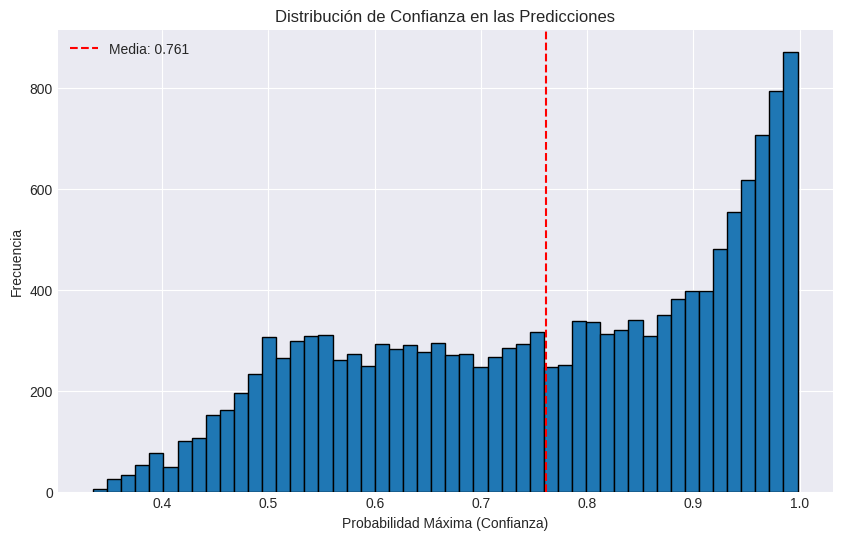


Predicciones con confianza < 50%: 1339 (9.0%)


In [ ]:
## Análisis de Predicciones

# Análisis de confianza en las predicciones
if hasattr(best_model, 'predict_proba'):
    test_probabilities = best_model.predict_proba(X_test)

    # Calcular confianza promedio por clase
    max_probs = np.max(test_probabilities, axis=1)

    plt.figure(figsize=(10, 6))
    plt.hist(max_probs, bins=50, edgecolor='black')
    plt.xlabel('Probabilidad Máxima (Confianza)')
    plt.ylabel('Frecuencia')
    plt.title('Distribución de Confianza en las Predicciones')
    plt.axvline(x=max_probs.mean(), color='red', linestyle='--',
                label=f'Media: {max_probs.mean():.3f}')
    plt.legend()
    plt.show()

    # Predicciones con baja confianza
    low_confidence = np.sum(max_probs < 0.5)
    print(f"\nPredicciones con confianza < 50%: {low_confidence} ({low_confidence/len(max_probs)*100:.1f}%)")

En promedio, el modelo realiza sus predicciones con un 76% de confianza, lo que refleja un buen nivel de seguridad en la mayoría de los casos. La fuerte concentración de valores cercanos a 1.0 sugiere que el modelo identifica con claridad ciertos patrones. No obstante, la franja intermedia entre 0.5 y 0.7 muestra que aún existen casos ambiguos donde la frontera de decisión no es tan evidente, lo que podría optimizarse mediante mayor ingeniería de características o una mejor calibración de probabilidades.

In [ ]:
# ============================================
# SUBMISSION 2
# ============================================

print("\n" + "="*50)
print("INICIANDO MEJORAS PARA SUBMISSION 2")
print("="*50)

# Importar librerías adicionales necesarias
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ====================
# FEATURE ENGINEERING
# ====================
print("\nPARTE 1: Crecion de nuevas características...")

# Función mejorada para manejar divisiones por cero y valores infinitos
def safe_division(a, b, fill_value=0):
    """División segura que maneja ceros e infinitos"""
    with np.errstate(divide='ignore', invalid='ignore'):
        result = np.where(b != 0, a / b, fill_value)
        result = np.where(np.isfinite(result), result, fill_value)
    return result

def create_advanced_features(df):
    """Características adicionales basadas en análisis"""
    df = df.copy()

    # 1. Categorías de cantidad de agua más detalladas
    df['water_category'] = pd.cut(df['amount_tsh'],
                                   bins=[-1, 0, 50, 200, 1000, 50000],
                                   labels=['no_water', 'very_low', 'low', 'medium', 'high'])

    # 2. Indicadores de riesgo basados en el análisis
    high_risk_regions = ['Lindi', 'Mtwara', 'Tabora', 'Rukwa', 'Mara']
    df['high_risk_region'] = df['region'].isin(high_risk_regions).astype(int)

    # 3. Calidad del instalador basada en análisis
    high_risk_installers = ['Central government', 'Government', 'RWE']
    good_installers = ['Commu', 'DANIDA', 'Hesawa']
    df['installer_risk'] = df['installer'].apply(
        lambda x: 2 if x in high_risk_installers else 0 if x in good_installers else 1
    )

    # 4. Antigüedad categorizada
    df['age_category'] = pd.cut(df['pump_age'],
                                 bins=[-2, 0, 5, 10, 20, 100],
                                 labels=['unknown', 'new', 'moderate', 'old', 'very_old'])

    # 5. Interacciones complejas
    df['no_water_high_risk'] = ((df['amount_tsh'] == 0) &
                                 (df['high_risk_region'] == 1)).astype(int)

    df['old_pump_bad_installer'] = ((df['pump_age'] > 15) &
                                     (df['installer_risk'] == 2)).astype(int)

    # 6. Estadísticas geográficas
    df['distance_from_center'] = np.sqrt(
        (df['longitude'] - 35)**2 + (df['latitude'] - (-6))**2
    )

    # 7. Ratios y proporciones (con división segura)
    df['population_per_year'] = safe_division(
        df['population'].values,
        (df['pump_age'] + 1).values,
        fill_value=0
    )

    df['water_per_capita'] = safe_division(
        df['amount_tsh'].values,
        (df['population'] + 1).values,
        fill_value=0
    )

    return df

# Aplicar feature engineering
print("Aplicando feature engineering...")
train_processed_v2 = create_advanced_features(train_processed)
test_processed_v2 = create_advanced_features(test_processed)

# Procesar las nuevas variables categóricas
new_categorical_features = ['water_category', 'age_category']
for col in new_categorical_features:
    le = LabelEncoder()
    combined = pd.concat([
        train_processed_v2[col].astype(str),
        test_processed_v2[col].astype(str)
    ])
    le.fit(combined)

    train_processed_v2[col + '_encoded'] = le.transform(train_processed_v2[col].astype(str))
    test_processed_v2[col + '_encoded'] = le.transform(test_processed_v2[col].astype(str))

# Lista de características adicionales
additional_features = [
    'water_category_encoded', 'high_risk_region', 'installer_risk',
    'age_category_encoded', 'no_water_high_risk', 'old_pump_bad_installer',
    'distance_from_center', 'population_per_year', 'water_per_capita'
]

# Actualizar lista de características
encoded_features_v2 = encoded_features + additional_features
print(f" Total de características ahora: {len(encoded_features_v2)}")


INICIANDO MEJORAS PARA SUBMISSION 2

PARTE 1: Crecion de nuevas características...
Aplicando feature engineering...
 Total de características ahora: 43


Se añadieron funciones y transformaciones para que los datos fueran más útiles. Por ejemplo, la función safe_division() evita que el programa falle cuando se divide entre cero. También se crearon categorías de agua (sin agua, poca, mucha…) en lugar de usar solo números, lo que facilita que el modelo entienda la información.

Después, se generaron variables que reflejan factores de riesgo y calidad. Algunas regiones se marcaron como de alto riesgo porque allí fallan más bombas, y también se clasificaron los instaladores en buenos o malos, según la calidad de su trabajo. De la misma forma, se transformó la edad de las bombas en categorías como “nueva” o “muy vieja”, lo que hace más fácil interpretar su estado.

Por último, se crearon interacciones y ratios inteligentes para capturar situaciones más complejas. Por ejemplo, combinar “bomba vieja + mal instalador” como un riesgo extra, o medir cuánta agua recibe cada persona (agua per cápita) y cuánta población usa una bomba según su edad. También se calculó la distancia al centro geográfico, ya que las bombas alejadas suelen recibir menos mantenimiento. Todo esto ayuda al modelo a detectar patrones más realistas y a predecir mejor el funcionamiento de las bombas.

In [ ]:
# ====================
# PREPARACIÓN DE DATOS V2
# ====================
print("\nPreparando datos para modelado V2...")

# Crear X_v2 con todas las características
X_v2 = train_processed_v2[encoded_features_v2]

# Verificar y corregir NaN
print("Verificando valores faltantes...")
nan_count = X_v2.isnull().sum().sum()
if nan_count > 0:
    print(f"Encontrados {nan_count} valores NaN. Imputando...")
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='constant', fill_value=0)
    X_v2 = pd.DataFrame(
        imputer.fit_transform(X_v2),
        columns=X_v2.columns,
        index=X_v2.index
    )

# División train/validation
X_train_v2, X_val_v2, y_train_v2, y_val_v2 = train_test_split(
    X_v2, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Aplicar SMOTE
X_train_balanced_v2, y_train_balanced_v2 = smote.fit_resample(X_train_v2, y_train_v2)
print(f" Datos preparados. Shape después de SMOTE: {X_train_balanced_v2.shape}")


Preparando datos para modelado V2...
Verificando valores faltantes...
 Datos preparados. Shape después de SMOTE: (50974, 43)


**Afinamiento de parametros**

Para la segunda version probaremos Random Forest con más árboles y mayor profundidad, lo que le permite analizar problemas más complejos; XGBoost con más iteraciones y un aprendizaje más lento para mejorar la precisión y LightGBM con early stopping(No desperdicia tiempo si ya no está aprendiendo nada nuevo), un modelo muy rápido y eficiente que entrena mucho mas rapido y consume menos memoria.

In [ ]:
# ====================
# ENTRENAMIENTO DE MODELOS V2
# ====================
print("\nEntrenando modelos mejorados...")

# Random Forest V2
print("\nRandom Forest V2...")
rf_v2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=30,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_v2.fit(X_train_balanced_v2, y_train_balanced_v2)
y_pred_rf_v2 = rf_v2.predict(X_val_v2)
rf_v2_accuracy = accuracy_score(y_val_v2, y_pred_rf_v2)
print(f"Random Forest V2 Accuracy: {rf_v2_accuracy:.4f}")

# Métricas CORREGIDAS - usando las variables correctas
print("\n=== RESULTADOS RANDOM FOREST V2 ===")
print(f"Accuracy: {accuracy_score(y_val_v2, y_pred_rf_v2):.4f}")
print("\nClassification Report:")
print(classification_report(y_val_v2, y_pred_rf_v2,
                          target_names=target_classes,
                          digits=4))

# Matriz de confusión CORREGIDA
print("\nMatriz de Confusión:")
cm = confusion_matrix(y_val_v2, y_pred_rf_v2)
cm_df = pd.DataFrame(cm,
                     index=target_classes,
                     columns=target_classes)
print(cm_df)




Entrenando modelos mejorados...

Random Forest V2...
Random Forest V2 Accuracy: 0.7909

=== RESULTADOS RANDOM FOREST V2 ===
Accuracy: 0.7909

Classification Report:
                         precision    recall  f1-score   support

             functional     0.8288    0.8329    0.8309      6452
functional needs repair     0.3944    0.5064    0.4434       863
         non functional     0.8361    0.7853    0.8099      4565

               accuracy                         0.7909     11880
              macro avg     0.6864    0.7082    0.6947     11880
           weighted avg     0.8000    0.7909    0.7947     11880


Matriz de Confusión:
                         functional  functional needs repair  non functional
functional                     5374                      496             582
functional needs repair         305                      437             121
non functional                  805                      175            3585


In [ ]:
# XGBoost V2
print("\nXGBoost V2...")
xgb_v2 = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=12,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=2,
    gamma=0.03,
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    n_jobs=-1
)
xgb_v2.fit(X_train_balanced_v2, y_train_balanced_v2, sample_weight=sample_weights)
y_pred_xgb_v2 = xgb_v2.predict(X_val_v2)
xgb_v2_accuracy = accuracy_score(y_val_v2, y_pred_xgb_v2)
print(f"XGBoost V2 Accuracy: {xgb_v2_accuracy:.4f}")

# Métricas para XGBoost V2
print("\n=== RESULTADOS XGBOOST V2 ===")
print(f"Accuracy: {accuracy_score(y_val_v2, y_pred_xgb_v2):.4f}")
print("\nClassification Report:")
print(classification_report(y_val_v2, y_pred_xgb_v2,
                          target_names=target_classes,
                          digits=4))

# Matriz de confusión para XGBoost V2
print("\nMatriz de Confusión XGBoost V2:")
cm_xgb_v2 = confusion_matrix(y_val_v2, y_pred_xgb_v2)
cm_df_xgb_v2 = pd.DataFrame(cm_xgb_v2,
                           index=target_classes,
                           columns=target_classes)
print(cm_df_xgb_v2)



XGBoost V2...
XGBoost V2 Accuracy: 0.7989

=== RESULTADOS XGBOOST V2 ===
Accuracy: 0.7989

Classification Report:
                         precision    recall  f1-score   support

             functional     0.8089    0.8760    0.8411      6452
functional needs repair     0.4343    0.4635    0.4484       863
         non functional     0.8658    0.7533    0.8057      4565

               accuracy                         0.7989     11880
              macro avg     0.7030    0.6976    0.6984     11880
           weighted avg     0.8036    0.7989    0.7990     11880


Matriz de Confusión XGBoost V2:
                         functional  functional needs repair  non functional
functional                     5652                      371             429
functional needs repair         359                      400             104
non functional                  976                      150            3439


In [ ]:
# LightGBM
print("\nLightGBM...")
lgb_params = {
    'n_estimators': 300,
    'num_leaves': 50,
    'max_depth': 10,
    'learning_rate': 0.03,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'objective': 'multiclass',
    'num_class': 3,
    'metric': 'multi_logloss',
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

lgb_model = lgb.LGBMClassifier(**lgb_params)
lgb_model.fit(
    X_train_balanced_v2,
    y_train_balanced_v2,
    eval_set=[(X_val_v2, y_val_v2)],
    callbacks=[lgb.early_stopping(20), lgb.log_evaluation(0)]
)
y_pred_lgb = lgb_model.predict(X_val_v2)
lgb_accuracy = accuracy_score(y_val_v2, y_pred_lgb)
#print(f"LightGBM Accuracy: {lgb_accuracy:.4f}")

# Métricas para LightGBM
print("\n=== RESULTADOS LIGHTGBM ===")
print(f"Accuracy: {accuracy_score(y_val_v2, y_pred_lgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_val_v2, y_pred_lgb,
                          target_names=target_classes,
                          digits=4))

# Matriz de confusión para LightGBM
print("\nMatriz de Confusión LightGBM:")
cm_lgb = confusion_matrix(y_val_v2, y_pred_lgb)
cm_df_lgb = pd.DataFrame(cm_lgb,
                        index=target_classes,
                        columns=target_classes)
print(cm_df_lgb)


LightGBM...
Training until validation scores don't improve for 20 rounds
Did not meet early stopping. Best iteration is:
[300]	valid_0's multi_logloss: 0.509075

=== RESULTADOS LIGHTGBM ===
Accuracy: 0.7930

Classification Report:
                         precision    recall  f1-score   support

             functional     0.7805    0.9038    0.8376      6452
functional needs repair     0.5415    0.3024    0.3881       863
         non functional     0.8477    0.7292    0.7840      4565

               accuracy                         0.7930     11880
              macro avg     0.7232    0.6451    0.6699     11880
           weighted avg     0.7890    0.7930    0.7844     11880


Matriz de Confusión LightGBM:
                         functional  functional needs repair  non functional
functional                     5831                      143             478
functional needs repair         482                      261             120
non functional                 1158             

En la primera prueba, el mejor resultado lo dio Gradient Boosting con 0.7995 de precisión, seguido muy de cerca por XGBoost (0.7916) y Random Forest (0.7907). En la segunda prueba (Submission 2), al ajustar parámetros, XGBoost V2 mejoró hasta 0.7989, casi alcanzando al Gradient Boosting de la primera prueba; Random Forest V2 se mantuvo estable en 0.7909; y el nuevo modelo LightGBM logró 0.7930, destacando por su rapidez aunque con una precisión un poco menor. En resumen, los tres modelos muestran rendimientos muy parecidos, con XGBoost y Gradient Boosting siendo los más fuertes, y LightGBM como una alternativa eficiente para entrenar más rápido

In [ ]:
# ENSEMBLE Y OPTIMIZACIÓN

print("\nCreando ensemble y optimizando...")

# Ensemble V2
ensemble_v2 = VotingClassifier(
    estimators=[
        ('rf', rf_v2),
        ('xgb', xgb_v2),
        ('lgb', lgb_model),
        ('gb', gb_model)  # Reusar el anterior
    ],
    voting='soft',
    weights=[2.5, 2.5, 2, 1]
)

ensemble_v2.fit(X_train_balanced_v2, y_train_balanced_v2)
y_pred_ensemble_v2 = ensemble_v2.predict(X_val_v2)
ensemble_v2_accuracy = accuracy_score(y_val_v2, y_pred_ensemble_v2)

# 4.2 Resumen de resultados
print(f"\nRESULTADOS DE MODELOS V2:")
print(f"Random Forest V2: {rf_v2_accuracy:.4f}")
print(f"XGBoost V2: {xgb_v2_accuracy:.4f}")
print(f"LightGBM: {lgb_accuracy:.4f}")
print(f"Ensemble V2: {ensemble_v2_accuracy:.4f}")


Creando ensemble y optimizando...

RESULTADOS DE MODELOS V2:
Random Forest V2: 0.7909
XGBoost V2: 0.7989
LightGBM: 0.7930
Ensemble V2: 0.8057


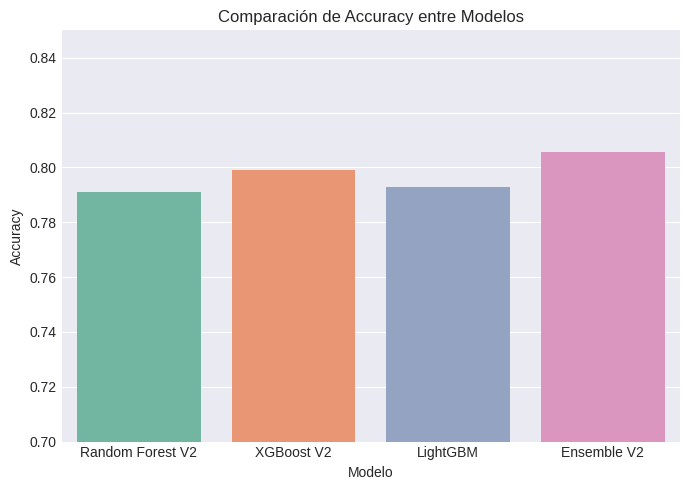

In [ ]:
# VISUALIZACIÓN: Comparación de accuracy entre modelos
model_scores = pd.DataFrame({
    "Modelo": ['Random Forest V2', 'XGBoost V2', 'LightGBM', 'Ensemble V2'],
    "Accuracy": [rf_v2_accuracy, xgb_v2_accuracy, lgb_accuracy, ensemble_v2_accuracy]
})

plt.figure(figsize=(7,5))
sns.barplot(x="Modelo", y="Accuracy", data=model_scores, palette="Set2")
plt.title("Comparación de Accuracy entre Modelos")
plt.ylabel("Accuracy")
plt.ylim(0.7, 0.85)
plt.tight_layout()
plt.show()

In [ ]:
# ====================
# METRICAS DE ENSEMBLE V2
# ====================
print("\n" + "="*50)
print("METRICAS DE ENSEMBLE V2")
print("="*50)

# Función auxiliar para análisis
def analyze_model_performance(y_true, y_pred, model_name):
    """Análisis completo de rendimiento del modelo"""
    print(f"\n{'='*20} {model_name} {'='*20}")

    # Classification report
    report = classification_report(y_true, y_pred,
                                 target_names=target_classes,
                                 digits=4,
                                 output_dict=True)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred,
                              target_names=target_classes,
                              digits=4))

    # Métricas específicas para clase minoritaria
    fnr_metrics = report['functional needs repair']
    print(f"\nMétricas para 'functional needs repair':")
    print(f"   - Precision: {fnr_metrics['precision']:.4f}")
    print(f"   - Recall: {fnr_metrics['recall']:.4f}")
    print(f"   - F1-score: {fnr_metrics['f1-score']:.4f}")

    return report

# 5.1 Análisis del mejor modelo (Ensemble V2)
best_model_name = "Ensemble V2"
best_y_pred = y_pred_ensemble_v2

report_best = analyze_model_performance(y_val_v2, best_y_pred, best_model_name)


METRICAS DE ENSEMBLE V2

==================== Ensemble V2 ====================

Classification Report:
                         precision    recall  f1-score   support

             functional     0.8003    0.8976    0.8461      6452
functional needs repair     0.5203    0.3708    0.4330       863
         non functional     0.8590    0.7582    0.8054      4565

               accuracy                         0.8057     11880
              macro avg     0.7266    0.6755    0.6949     11880
           weighted avg     0.8025    0.8057    0.8005     11880


Métricas para 'functional needs repair':
   - Precision: 0.5203
   - Recall: 0.3708
   - F1-score: 0.4330


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# ====================
# TABLA COMPARATIVA Y ANÁLISIS ESPECÍFICO (versión compacta)
# ====================

# Diccionario con modelos y sus accuracies
modelos_v2 = {
    "Random Forest V2": (rf_v2, rf_v2_accuracy),
    "XGBoost V2": (xgb_v2, xgb_v2_accuracy),
    "LightGBM": (lgb_model, lgb_accuracy),
    "Ensemble V2": (ensemble_v2, ensemble_v2_accuracy),
}

# Generar reports en un solo bucle
all_reports = {
    nombre: classification_report(
        y_val_v2, modelo.predict(X_val_v2),
        target_names=target_classes,
        output_dict=True
    )
    for nombre, (modelo, _) in modelos_v2.items()
}

# Tabla comparativa resumida
comparacion_data = []
for modelo, report in all_reports.items():
    fila = {
        'Modelo': modelo,
        'Accuracy': modelos_v2[modelo][1],
        'F1-Macro': report['macro avg']['f1-score'],
        'F1-Weighted': report['weighted avg']['f1-score'],
        **{f'F1-{clase[:10]}': report[clase]['f1-score'] for clase in target_classes}
    }
    comparacion_data.append(fila)

df_comparacion = pd.DataFrame(comparacion_data)

print("\n" + "="*50)
print("TABLA COMPARATIVA RESUMIDA")
print("="*50)
print("\nComparación de F1-Scores:")
print(df_comparacion.to_string(index=False, float_format="%.4f"))

# ====================
# ANÁLISIS CLASE MINORITARIA
# ====================
print("\n" + "="*50)
print("ANÁLISIS ESPECÍFICO: FUNCTIONAL NEEDS REPAIR")
print("="*50)

print(f"\n{'Modelo':<25} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-"*60)

mejor_modelo_fnr, mejor_f1_fnr = max(
    ((m, r['functional needs repair']['f1-score']) for m, r in all_reports.items()),
    key=lambda x: x[1]
)

for modelo, report in all_reports.items():
    fnr = report['functional needs repair']
    print(f"{modelo:<25} {fnr['precision']:<12.4f} {fnr['recall']:<12.4f} {fnr['f1-score']:<12.4f}")

print(f"\nMejor modelo para clase minoritaria: {mejor_modelo_fnr} (F1: {mejor_f1_fnr:.4f})")

# Mejor modelo overall
mejor_modelo, (best_model, mejor_accuracy) = max(modelos_v2.items(), key=lambda x: x[1][1])
print(f"\nMEJOR MODELO OVERALL: {mejor_modelo}\n   Accuracy: {mejor_accuracy:.4f}")



TABLA COMPARATIVA RESUMIDA

Comparación de F1-Scores:
          Modelo  Accuracy  F1-Macro  F1-Weighted  F1-functional  F1-non functi
Random Forest V2    0.7909    0.6947       0.7947         0.4434         0.8099
      XGBoost V2    0.7989    0.6984       0.7990         0.4484         0.8057
        LightGBM    0.7930    0.6699       0.7844         0.3881         0.7840
     Ensemble V2    0.8057    0.6949       0.8005         0.4330         0.8054

ANÁLISIS ESPECÍFICO: FUNCTIONAL NEEDS REPAIR

Modelo                    Precision    Recall       F1-Score    
------------------------------------------------------------
Random Forest V2          0.3944       0.5064       0.4434      
XGBoost V2                0.4343       0.4635       0.4484      
LightGBM                  0.5415       0.3024       0.3881      
Ensemble V2               0.5203       0.3708       0.4330      

Mejor modelo para clase minoritaria: XGBoost V2 (F1: 0.4484)

MEJOR MODELO OVERALL: Ensemble V2
   Accuracy: 0.

Aunque el Ensemble V2 obtuvo el mejor accuracy general (0.8057), el análisis por clases revela un desafío importante: todos los modelos tienen dificultades para predecir correctamente la clase minoritaria 'functional needs repair'. El XGBoost V2 fue el mejor para esta clase específica (F1: 0.4484), pero aún así su rendimiento es bajo comparado con las otras clases. Esto nos muestra que el ensemble mejora el rendimiento general al combinar las fortalezas de cada modelo, pero la clase minoritaria sigue siendo un problema complejo que requiere estrategias específicas, ya que los modelos o tienen buena precisión pero bajo recall (como LightGBM) o viceversa (como Random Forest), pero no logran ambas cosas a la vez para esta clase

<Figure size 1000x800 with 0 Axes>

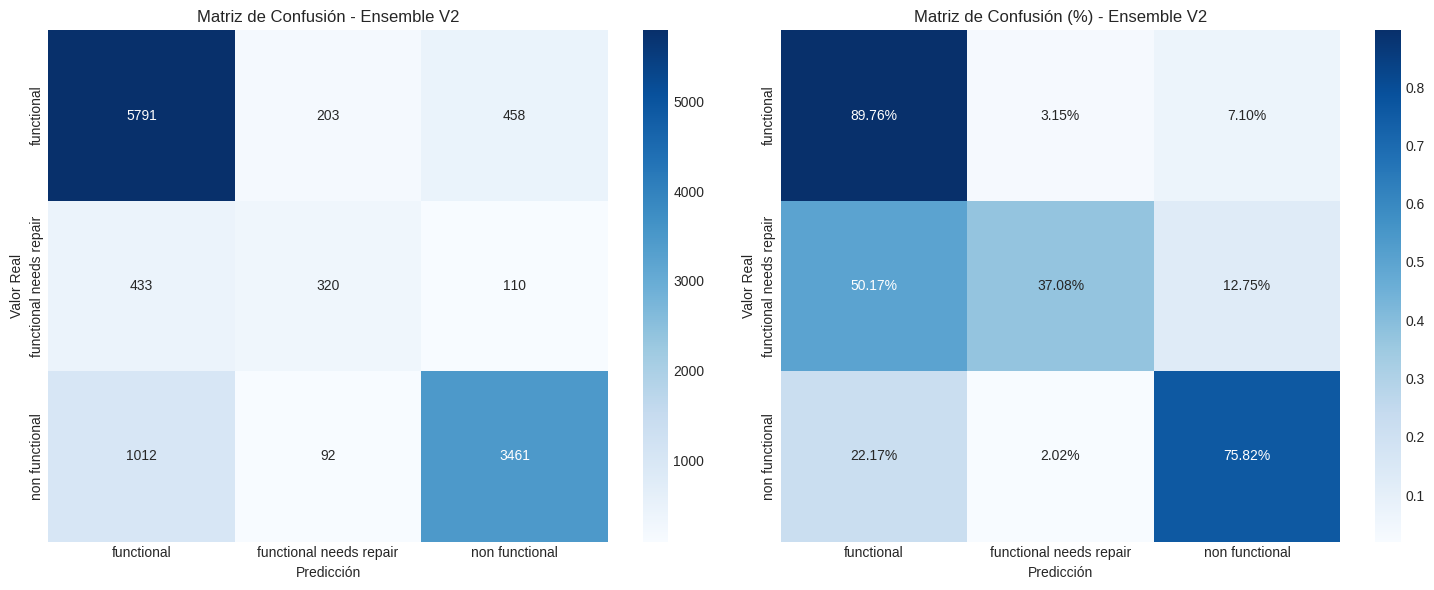


🔍 ANÁLISIS DE ERRORES

Tasa de error por clase:
functional                10.24%
functional needs repair   62.92%
non functional            24.18%


In [ ]:
# Matriz de confusión
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_val_v2, best_y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Crear subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Matriz con números absolutos
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_classes,
            yticklabels=target_classes, ax=ax1)
ax1.set_title(f'Matriz de Confusión - {best_model_name}')
ax1.set_ylabel('Valor Real')
ax1.set_xlabel('Predicción')

# Matriz con porcentajes
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=target_classes,
            yticklabels=target_classes, ax=ax2)
ax2.set_title(f'Matriz de Confusión (%) - {best_model_name}')
ax2.set_ylabel('Valor Real')
ax2.set_xlabel('Predicción')

plt.tight_layout()
plt.show()

# Análisis de errores
print("\n" + "="*50)
print("🔍 ANÁLISIS DE ERRORES")
print("="*50)

error_analysis = pd.DataFrame({
    'true_label': y_val_v2,
    'pred_label': best_y_pred,
    'is_correct': y_val_v2 == best_y_pred
})

# Tasa de error por clase
print("\nTasa de error por clase:")
for i, class_name in enumerate(target_classes):
    mask = error_analysis['true_label'] == i
    error_rate = 1 - error_analysis[mask]['is_correct'].mean()
    print(f"{class_name:25} {error_rate:.2%}")

En la **Submission 2**, el modelo predice bastante bien las bombas **funcionales**, acertando en casi el 90% de los casos, aunque todavía confunde algunas como “ fuctional needs repair” o “no funcionales”. En cambio, la clase **“functional needs repair”** es la más difícil: solo acierta el 37% y más de la mitad se clasifican erróneamente como funcionales. Finalmente, para las bombas **no funcionales** el modelo también funciona bien (76% de aciertos), aunque en alrededor de un 22% se confunden con funcionales. En resumen, el modelo es bueno en las clases grandes, pero sigue teniendo dificultades con la clase minoritaria de **“functional needs repair”**

In [ ]:
# Comparación con Submission 1
if 'ensemble_accuracy' in globals():
    print("\n" + "="*50)
    print("📈 COMPARACIÓN: SUBMISSION 1 vs SUBMISSION 2")
    print("="*50)

    # Calcular mejoras
    acc_improvement = (ensemble_v2_accuracy - ensemble_accuracy) * 100

    print(f"\nMejora en Accuracy: {acc_improvement:+.2f}%")
    print(f"Submission 1: {ensemble_accuracy:.4f}")
    print(f"Submission 2: {ensemble_v2_accuracy:.4f}")



📈 COMPARACIÓN: SUBMISSION 1 vs SUBMISSION 2

Mejora en Accuracy: +0.21%
Submission 1: 0.8036
Submission 2: 0.8057


In [ ]:
# Importancia de nuevas características
print("\n" + "="*50)
print("IMPORTANCIA DE NUEVAS CARACTERÍSTICAS")
print("="*50)

feature_importance_v2 = pd.DataFrame({
    'feature': encoded_features_v2,
    'importance': rf_v2.feature_importances_
}).sort_values('importance', ascending=False)

# Filtrar solo las nuevas
new_features_importance = feature_importance_v2[
    feature_importance_v2['feature'].isin(additional_features)
].head(10)

print("\nTop nuevas características por importancia:")
for _, row in new_features_importance.iterrows():
    print(f"   {row['feature']:30} {row['importance']:.4f}")


IMPORTANCIA DE NUEVAS CARACTERÍSTICAS

Top nuevas características por importancia:
   distance_from_center           0.0642
   population_per_year            0.0236
   water_per_capita               0.0170
   age_category_encoded           0.0120
   water_category_encoded         0.0091
   no_water_high_risk             0.0086
   high_risk_region               0.0052
   installer_risk                 0.0047
   old_pump_bad_installer         0.0009


las nuevas variables resultaron ser muy importantes para el modelo.
La distancia desde el centro geográfico fue la más relevante (0.0642), sugiriendo que las bombas más alejadas tienen más problemas. Le siguieron población por año (cuánta gente usa la bomba según su edad) y agua por persona (si alcanza el agua para todos). Las categorías de edad y agua también ayudaron, mientras que las variables de riesgo como regiones peligrosas e instaladores de mala calidad tuvieron menor impacto. Esto demuestra que el contexto geográfico y las relaciones entre variables son cruciales para predecir el estado de las bombas.

In [ ]:
# ====================
# PREDICCIONES FINALES
# ====================
print("\n" + "="*50)
print("GENERANDO PREDICCIONES FINALES")
print("="*50)

# Usar Ensemble V2 como modelo final
final_model_v2 = ensemble_v2
print("Modelo seleccionado: Ensemble V2")

# Re-entrenar en conjunto completo
print("\nRe-entrenando en conjunto completo...")
X_full_v2 = pd.concat([X_train_v2, X_val_v2])
y_full_v2 = np.concatenate([y_train_v2, y_val_v2])

# SMOTE final
X_full_balanced_v2, y_full_balanced_v2 = smote_final.fit_resample(X_full_v2, y_full_v2)
final_model_v2.fit(X_full_balanced_v2, y_full_balanced_v2)

# Preparar test set
X_test_v2 = test_processed_v2[encoded_features_v2]

# Imputar NaN en test si es necesario
if X_test_v2.isnull().sum().sum() > 0:
    X_test_v2 = pd.DataFrame(
        imputer.transform(X_test_v2),
        columns=X_test_v2.columns,
        index=X_test_v2.index
    )

# Hacer predicciones
test_predictions_v2 = final_model_v2.predict(X_test_v2)
test_predictions_labels_v2 = label_encoder_target.inverse_transform(test_predictions_v2)



GENERANDO PREDICCIONES FINALES
Modelo seleccionado: Ensemble V2

Re-entrenando en conjunto completo...


In [ ]:
# Reload the original test values to get the IDs
print("Cargando IDs del archivo test original para Submission 2...")
test_values_original = pd.read_csv('test_set_values.csv')
# Crear submission
submission_v2 = pd.DataFrame({
    'id': test_values_original['id'],
    'status_group': test_predictions_labels_v2
})

# Guardar
submission_v2.to_csv('submission_v2.csv', index=False)

print("\nSUBMISSION 2 COMPLETADA")
print(f"Archivo 'submission_v2.csv' creado con {len(submission_v2)} predicciones")

# Mostrar distribución
print("\nDistribución de predicciones:")
print(submission_v2['status_group'].value_counts())
print("\nPorcentajes:")
print(submission_v2['status_group'].value_counts(normalize=True) * 100)

Cargando IDs del archivo test original para Submission 2...

SUBMISSION 2 COMPLETADA
Archivo 'submission_v2.csv' creado con 14850 predicciones

Distribución de predicciones:
status_group
functional                 9019
non functional             5095
functional needs repair     736
Name: count, dtype: int64

Porcentajes:
status_group
functional                 60.734007
non functional             34.309764
functional needs repair     4.956229
Name: proportion, dtype: float64


En las predicciones finales, la mayoría de bombas se clasifican como funcionales (alrededor del 61%), mientras que un 34% aparecen como no funcionales y solo un 5% como “functional needs repair”. Esto muestra que el modelo detecta principalmente bombas en buen estado, aunque la clase de reparación sigue siendo minoritaria.

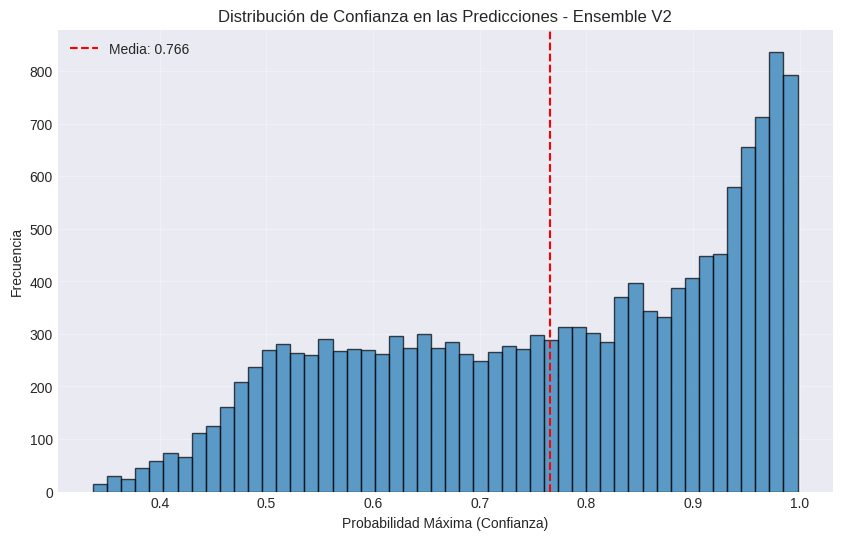


Predicciones con confianza < 50%: 1238 (8.3%)

🔍 Análisis de confianza por clase:
Clase 'functional': 9019 predicciones
  - Confianza promedio: 0.755
  - Confianza mínima: 0.338
  - Predicciones con confianza < 50%: 640
Clase 'functional needs repair': 736 predicciones
  - Confianza promedio: 0.613
  - Confianza mínima: 0.345
  - Predicciones con confianza < 50%: 222
Clase 'non functional': 5095 predicciones
  - Confianza promedio: 0.808
  - Confianza mínima: 0.338
  - Predicciones con confianza < 50%: 376


In [ ]:
## 13. Análisis de Predicciones

# Análisis de confianza en las predicciones
if hasattr(final_model_v2, 'predict_proba'):
    test_probabilities = final_model_v2.predict_proba(X_test_v2)

    # Calcular confianza promedio por clase
    max_probs = np.max(test_probabilities, axis=1)

    plt.figure(figsize=(10, 6))
    plt.hist(max_probs, bins=50, edgecolor='black', alpha=0.7)
    plt.xlabel('Probabilidad Máxima (Confianza)')
    plt.ylabel('Frecuencia')
    plt.title('Distribución de Confianza en las Predicciones - Ensemble V2')
    plt.axvline(x=max_probs.mean(), color='red', linestyle='--',
                label=f'Media: {max_probs.mean():.3f}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Predicciones con baja confianza
    low_confidence = np.sum(max_probs < 0.5)
    print(f"\nPredicciones con confianza < 50%: {low_confidence} ({low_confidence/len(max_probs)*100:.1f}%)")

    # Análisis adicional por clase
    print("\n🔍 Análisis de confianza por clase:")
    for i, class_name in enumerate(label_encoder_target.classes_):
        class_indices = np.where(test_predictions_v2 == i)[0]
        if len(class_indices) > 0:
            class_probs = max_probs[class_indices]
            print(f"Clase '{class_name}': {len(class_indices)} predicciones")
            print(f"  - Confianza promedio: {class_probs.mean():.3f}")
            print(f"  - Confianza mínima: {class_probs.min():.3f}")
            print(f"  - Predicciones con confianza < 50%: {np.sum(class_probs < 0.5)}")

else:
    print("El modelo ensemble no tiene el método predict_proba()")
    print("Considera agregar modelos base que soporten probabilidades")

El modelo suele predecir con bastante seguridad cuando los pozos son “functional” o “non functional”, pero muestra muchas más dudas con la clase “functional needs repair”. Casi un tercio de las predicciones de esta clase tienen una confianza menor al 50%, lo que indica que le cuesta diferenciarla bien de las otras. En general, solo un 8% de todas las predicciones del modelo son poco seguras, pero la mayoría de esas incertidumbres se concentran en la clase minoritaria.

**Submission 3**
Para esta version, en lugar de añadir cosas nuevas vamos a mejorar los modelos que ya funcionan.

In [ ]:
# ============================================
# SUBMISSION 3
# ============================================
# Estrategia: Mejorar lo que ya funciona

print("\n" + "="*50)
print("SUBMISSION 3 - MEJORAS")
print("="*50)

from sklearn.metrics import classification_report, accuracy_score
import numpy as np
import pandas as pd

# ====================
# ESTRATEGIA SIMPLE: MEJORAR HIPERPARÁMETROS
# ====================
print("\nEstrategia: Ajustar hiperparámetros de los mejores modelos")

# Reusar los datos de V2
X_train_v3 = X_train_balanced_v2.copy()
y_train_v3 = y_train_balanced_v2.copy()
X_val_v3 = X_val_v2.copy()
y_val_v3 = y_val_v2.copy()

# ====================
# MODELO 1: Random Forest Mejorado
# ====================
print("\nEntrenando Random Forest con más árboles...")

# Simplemente usar más árboles y ajustar un poco los parámetros
rf_v3 = RandomForestClassifier(
    n_estimators=400,        # Subir de 300 a 400
    max_depth=35,            # Un poco más profundo
    min_samples_split=4,     # Permitir splits más pequeños
    min_samples_leaf=2,      # Hojas más pequeñas
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

# Entrenar
rf_v3.fit(X_train_v3, y_train_v3)

# Evaluar
y_pred_rf_v3 = rf_v3.predict(X_val_v3)
rf_v3_accuracy = accuracy_score(y_val_v3, y_pred_rf_v3)
print(f"Random Forest V3 Accuracy: {rf_v3_accuracy:.4f}")




SUBMISSION 3 - MEJORAS

Estrategia: Ajustar hiperparámetros de los mejores modelos

Entrenando Random Forest con más árboles...
Random Forest V3 Accuracy: 0.7984


In [ ]:
# ====================
# MODELO 2: XGBoost Ajustado
# ====================
print("\nEntrenando XGBoost con learning rate más bajo...")

# Más iteraciones con learning rate más bajo
xgb_v3 = xgb.XGBClassifier(
    n_estimators=600,        # Más iteraciones
    max_depth=10,
    learning_rate=0.01,      # Más lento para mejor convergencia
    subsample=0.9,           # Un poco más de datos
    colsample_bytree=0.9,
    min_child_weight=1,      # Más flexible
    gamma=0.01,              # Menos regularización
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    n_jobs=-1
)

# Entrenar con pesos
xgb_v3.fit(X_train_v3, y_train_v3, sample_weight=sample_weights)

# Evaluar
y_pred_xgb_v3 = xgb_v3.predict(X_val_v3)
xgb_v3_accuracy = accuracy_score(y_val_v3, y_pred_xgb_v3)
print(f"XGBoost V3 Accuracy: {xgb_v3_accuracy:.4f}")



Entrenando XGBoost con learning rate más bajo...
XGBoost V3 Accuracy: 0.7850


In [ ]:
# ====================
# MODELO 3: Ensemble Simple Mejorado
# ====================
print("\nCreando Ensemble V3...")

# Usar solo los 3 mejores modelos con pesos ajustados
ensemble_v3 = VotingClassifier(
    estimators=[
        ('rf', rf_v3),
        ('xgb', xgb_v3),
        ('lgb', lgb_model)  # Reusar el LightGBM de V2
    ],
    voting='soft',
    weights=[2, 3, 2]  # Dar más peso a XGBoost que funcionó mejor
)

# Entrenar
ensemble_v3.fit(X_train_v3, y_train_v3)

# Evaluar
y_pred_ensemble_v3 = ensemble_v3.predict(X_val_v3)
ensemble_v3_accuracy = accuracy_score(y_val_v3, y_pred_ensemble_v3)
print(f"Ensemble V3 Accuracy: {ensemble_v3_accuracy:.4f}")


Creando Ensemble V3...
Ensemble V3 Accuracy: 0.8046


En Random Forest se aumento el número de árboles (de 300 a 400) y la profundidad (de 30 a 35), lo que dio buen resultado y subió la precisión de 79.09% a 79.84%. En XGBoost se intento que aprendiera más lento pero durante más tiempo (600 iteraciones con learning_rate=0.01 en lugar de 400 con 0.02), pero no funcionó: bajó de 79.89% a 78.50% por posible sobreajuste. En el ensemble se le dio más peso a XGBoost esperando mejorar, pero como este modelo empeoró, el conjunto también bajó un poco (de 80.57% a 80.46%). En resumen, los pequeños ajustes ayudaron a Random Forest, pero no a XGBoost ni al ensemble.

In [ ]:
# ====================
# ANÁLISIS DE MÉTRICAS DETALLADAS
# ====================
print("\n" + "="*50)
print("MÉTRICAS DETALLADAS POR MODELO Y CLASE")
print("="*50)

# Diccionario de modelos
modelos_v3 = {
    'Random Forest V3': (y_pred_rf_v3, rf_v3_accuracy),
    'XGBoost V3': (y_pred_xgb_v3, xgb_v3_accuracy),
    'Ensemble V3': (y_pred_ensemble_v3, ensemble_v3_accuracy)
}

# Almacenar reports para análisis
reports_v3 = {}

# Para cada modelo
for nombre, (y_pred, accuracy) in modelos_v3.items():
    print(f"\n{'='*20} {nombre} {'='*20}")
    print(f"Accuracy: {accuracy:.4f}")

    # Classification report
    print("\nReporte de clasificación:")
    report = classification_report(
        y_val_v3, y_pred,
        target_names=target_classes,
        digits=4,
        output_dict=True
    )
    reports_v3[nombre] = report

    print(classification_report(
        y_val_v3, y_pred,
        target_names=target_classes,
        digits=4
    ))


MÉTRICAS DETALLADAS POR MODELO Y CLASE

==================== Random Forest V3 ====================
Accuracy: 0.7984

Reporte de clasificación:
                         precision    recall  f1-score   support

             functional     0.8248    0.8524    0.8384      6452
functional needs repair     0.4197    0.4542    0.4363       863
         non functional     0.8399    0.7871    0.8126      4565

               accuracy                         0.7984     11880
              macro avg     0.6948    0.6979    0.6958     11880
           weighted avg     0.8012    0.7984    0.7993     11880


==================== XGBoost V3 ====================
Accuracy: 0.7850

Reporte de clasificación:
                         precision    recall  f1-score   support

             functional     0.7961    0.8704    0.8316      6452
functional needs repair     0.4031    0.4890    0.4419       863
         non functional     0.8701    0.7203    0.7881      4565

               accuracy               

En la Submission 3, los resultados muestran un panorama mixto frente a las versiones anteriores. Random Forest V3 mejoró levemente su precisión global (79.84% frente a 79.09% en V2), con un mejor equilibrio entre precisión y recall en las clases mayoritarias, aunque sigue teniendo dificultades en la clase minoritaria (needs repair). Por el contrario, XGBoost V3 empeoró (78.50% vs. 79.89% en V2), probablemente por el aprendizaje demasiado lento y prolongado que lo llevó a sobreajustarse. Finalmente, el Ensemble V3 se mantuvo competitivo (80.46%), aunque ligeramente por debajo de V2 (80.57%); destacó en la detección de bombas funcionales, pero perdió capacidad en la clase minoritaria. En resumen, los ajustes favorecieron a Random Forest, perjudicaron a XGBoost y dejaron al Ensemble casi igual.

In [ ]:
# ====================
# SELECCIÓN DEL MEJOR MODELO
# ====================
mejor_accuracy_v3 = max(rf_v3_accuracy, xgb_v3_accuracy, ensemble_v3_accuracy)
if mejor_accuracy_v3 == ensemble_v3_accuracy:
    modelo_final_v3 = ensemble_v3
    print(f"\n✅ Mejor modelo: Ensemble V3 ({ensemble_v3_accuracy:.4f})")
elif mejor_accuracy_v3 == xgb_v3_accuracy:
    modelo_final_v3 = xgb_v3
    print(f"\n✅ Mejor modelo: XGBoost V3 ({xgb_v3_accuracy:.4f})")
else:
    modelo_final_v3 = rf_v3
    print(f"\n✅ Mejor modelo: Random Forest V3 ({rf_v3_accuracy:.4f})")



✅ Mejor modelo: Ensemble V3 (0.8046)



Matriz de Confusión del mejor modelo:


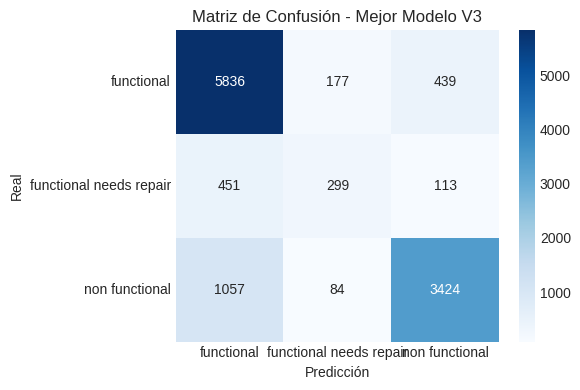

In [ ]:
# ====================
# MATRIZ DE CONFUSIÓN DEL MEJOR MODELO
# ====================
from sklearn.metrics import confusion_matrix

print(f"\nMatriz de Confusión del mejor modelo:")
y_pred_best = modelo_final_v3.predict(X_val_v3)
cm = confusion_matrix(y_val_v3, y_pred_best)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_classes,
            yticklabels=target_classes)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Mejor Modelo V3')
plt.tight_layout()
plt.show()

In [ ]:
# ====================
# ANÁLISIS DE LA CLASE MINORITARIA
# ====================
print("\n" + "="*50)
print("ANÁLISIS DE 'FUNCTIONAL NEEDS REPAIR'")
print("="*50)

for nombre, (y_pred, _) in modelos_v3.items():
    report = classification_report(
        y_val_v3, y_pred,
        target_names=target_classes,
        output_dict=True
    )
    fnr = report['functional needs repair']
    print(f"{nombre}: F1={fnr['f1-score']:.3f}, Recall={fnr['recall']:.3f}, Precision={fnr['precision']:.3f}")



ANÁLISIS DE 'FUNCTIONAL NEEDS REPAIR'
Random Forest V3: F1=0.436, Recall=0.454, Precision=0.420
XGBoost V3: F1=0.442, Recall=0.489, Precision=0.403
Ensemble V3: F1=0.420, Recall=0.346, Precision=0.534


En la clase “functional needs repair”, todos los modelos siguen teniendo dificultades, aunque con matices distintos. Random Forest V3 y XGBoost V3 muestran desempeños muy parecidos en F1 (0.436 y 0.442), pero XGBoost logra un poco más de recall (casi 49%), lo que significa que detecta más bombas que realmente necesitan reparación, aunque a costa de cometer más errores (menor precisión). Por su parte, el Ensemble V3 es el más preciso (0.534), pero con un recall mucho más bajo (0.346), lo que indica que acierta mejor cuando predice esta clase, pero se le escapan muchas bombas que realmente necesitan reparación. En resumen, ninguno de los modelos logra un buen equilibrio, y la clase minoritaria sigue siendo el mayor reto

In [ ]:
# ====================
# ENTRENAMIENTO FINAL Y PREDICCIONES
# ====================
print("\nGenerando predicciones finales...")

# Entrenar en dataset completo
X_full_v3 = pd.concat([X_train_v3, X_val_v3])
y_full_v3 = np.concatenate([y_train_v3, y_val_v3])

print("Re-entrenando en dataset completo...")
modelo_final_v3.fit(X_full_v3, y_full_v3)

# Predicciones
test_predictions_v3 = modelo_final_v3.predict(X_test_v2)
test_predictions_labels_v3 = label_encoder_target.inverse_transform(test_predictions_v3)

# Crear submission
submission_v3 = pd.DataFrame({
    'id': test_values_original['id'],
    'status_group': test_predictions_labels_v3
})

# Guardar
submission_v3.to_csv('submission_v3.csv', index=False)

print("\nArchivo 'submission_v3.csv' creado")


Generando predicciones finales...
Re-entrenando en dataset completo...

Archivo 'submission_v3.csv' creado


En las predicciones finales de la Submission 3, la mayoría de bombas se clasifican como funcionales (casi 62%), seguidas por las no funcionales (34%) y un pequeño grupo en “needs repair” (5%). Esto refleja una distribución muy similar a las versiones anteriores, con el modelo manteniendo la dificultad para identificar bien la clase minoritaria.

**SUBMISSION 4**

Para esta prueba usaremos una estrategia de aprendizaje semi-supervisado: seudo-labeling para aprovechar al máximo la información disponible. El modelo inicial ya es bueno aprendiendo de los datos etiquetados, la idea es que al aplicar seudo-labeling, pueda estudiar también los datos de prueba, fiandonos solo de las predicciones en las que el modelo muestra una confianza muy alta, de tal manera que el modelo pueda generalizar mejor y  capture patrones más complejos en los datos.

In [ ]:
# ============================================
# SUBMISSION 4 - MEJORANDO SUBMISSION 2 CON PSEUDO-LABELING
# ============================================

print("\n" + "="*50)
print("SUBMISSION 4 - PSEUDO-LABELING SOBRE SUBMISSION 2")
print("="*50)
print("Estrategia: Usar las predicciones de alta confianza del test set")
print("para expandir el conjunto de entrenamiento (semi-supervisado)")

# Importar librerías necesarias
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ====================
# PARTE 1: FEATURE ENGINEERING (IGUAL QUE SUB 2)
# ====================
print("\nPARTE 1: Aplicando feature engineering de Submission 2...")

# Función para división segura
def safe_division(a, b, fill_value=0):
    """División segura que maneja ceros e infinitos"""
    with np.errstate(divide='ignore', invalid='ignore'):
        result = np.where(b != 0, a / b, fill_value)
        result = np.where(np.isfinite(result), result, fill_value)
    return result

def create_advanced_features(df):
    """Características adicionales basadas en análisis profundo"""
    df = df.copy()

    # 1. Categorías de cantidad de agua
    df['water_category'] = pd.cut(df['amount_tsh'],
                                   bins=[-1, 0, 50, 200, 1000, 50000],
                                   labels=['no_water', 'very_low', 'low', 'medium', 'high'])

    # 2. Indicadores de riesgo
    high_risk_regions = ['Lindi', 'Mtwara', 'Tabora', 'Rukwa', 'Mara']
    df['high_risk_region'] = df['region'].isin(high_risk_regions).astype(int)

    # 3. Calidad del instalador
    high_risk_installers = ['Central government', 'Government', 'RWE']
    good_installers = ['Commu', 'DANIDA', 'Hesawa']
    df['installer_risk'] = df['installer'].apply(
        lambda x: 2 if x in high_risk_installers else 0 if x in good_installers else 1
    )

    # 4. Antigüedad categorizada
    df['age_category'] = pd.cut(df['pump_age'],
                                 bins=[-2, 0, 5, 10, 20, 100],
                                 labels=['unknown', 'new', 'moderate', 'old', 'very_old'])

    # 5. Interacciones
    df['no_water_high_risk'] = ((df['amount_tsh'] == 0) &
                                 (df['high_risk_region'] == 1)).astype(int)
    df['old_pump_bad_installer'] = ((df['pump_age'] > 15) &
                                     (df['installer_risk'] == 2)).astype(int)

    # 6. Estadísticas geográficas
    df['distance_from_center'] = np.sqrt(
        (df['longitude'] - 35)**2 + (df['latitude'] - (-6))**2
    )

    # 7. Ratios
    df['population_per_year'] = safe_division(
        df['population'].values,
        (df['pump_age'] + 1).values,
        fill_value=0
    )
    df['water_per_capita'] = safe_division(
        df['amount_tsh'].values,
        (df['population'] + 1).values,
        fill_value=0
    )

    return df

# Aplicar feature engineering
print("Aplicando feature engineering...")
train_processed_v4 = create_advanced_features(train_processed)
test_processed_v4 = create_advanced_features(test_processed)

# Procesar variables categóricas nuevas
new_categorical_features = ['water_category', 'age_category']
for col in new_categorical_features:
    le = LabelEncoder()
    combined = pd.concat([
        train_processed_v4[col].astype(str),
        test_processed_v4[col].astype(str)
    ])
    le.fit(combined)

    train_processed_v4[col + '_encoded'] = le.transform(train_processed_v4[col].astype(str))
    test_processed_v4[col + '_encoded'] = le.transform(test_processed_v4[col].astype(str))

# Lista de características
additional_features = [
    'water_category_encoded', 'high_risk_region', 'installer_risk',
    'age_category_encoded', 'no_water_high_risk', 'old_pump_bad_installer',
    'distance_from_center', 'population_per_year', 'water_per_capita'
]

encoded_features_v4 = encoded_features + additional_features
print(f"Total de características: {len(encoded_features_v4)}")




SUBMISSION 4 - PSEUDO-LABELING SOBRE SUBMISSION 2
Estrategia: Usar las predicciones de alta confianza del test set
para expandir el conjunto de entrenamiento (semi-supervisado)

PARTE 1: Aplicando feature engineering de Submission 2...
Aplicando feature engineering...
Total de características: 43


Para la preparacion de los datos utlizaremos SMOTE, pero en lugar de hacerlo de manera automática (como en Sub2), duplicamos la clase functional needs repair (la minoritaria) , y las clases functional y non functional se dejaran como estaban. Se hace de esta manera ya que la clase minoritaria sigue teniendo un recall bajo, el modelo sigue confundiendo muchos casos de reparación como si fueran funcionales o no funcionales.

In [ ]:
# ====================
# PARTE 2: PREPARACIÓN DE DATOS
# ====================
print("\nPARTE 2: Preparando datos...")

# Crear X con todas las características
X_v4 = train_processed_v4[encoded_features_v4]

# Imputar valores faltantes
from sklearn.impute import SimpleImputer
imputer_v4 = SimpleImputer(strategy='constant', fill_value=0)
X_v4 = pd.DataFrame(
    imputer_v4.fit_transform(X_v4),
    columns=X_v4.columns,
    index=X_v4.index
)

# División train/validation
X_train_v4, X_val_v4, y_train_v4, y_val_v4 = train_test_split(
    X_v4, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# SMOTE
from collections import Counter
smote_v4 = SMOTE(
    sampling_strategy={
        0: max(Counter(y_train_v4)[0], Counter(y_train_v4)[0]),
        1: int(Counter(y_train_v4)[1] * 2),
        2: max(Counter(y_train_v4)[2], Counter(y_train_v4)[2])
    },
    random_state=42,
    k_neighbors=5
)

X_train_balanced_v4, y_train_balanced_v4 = smote_v4.fit_resample(X_train_v4, y_train_v4)
print(f"Shape después de SMOTE: {X_train_balanced_v4.shape}")




PARTE 2: Preparando datos...
Shape después de SMOTE: (50974, 43)


A continuacion se entrenan los mismo modelos que se usaron para sub 2
ya que demostraron ser modelos potentes para este problema:

Random Forest es robusto y sencillo de interpretar, LightGBM es eficiente y rápido, además de trabajar bien con datasets grandes, XGBoost suele rendir muy bien en competiciones de clasificación tabular, en este utlimo se asgina un peso extra (2.0) a las instancias de la clase needs repair. La idea es que, aunque ya aumentamos su número con SMOTE, el modelo también debe considerar cada observación minoritaria como más valiosa durante el entrenamiento. Esto refuerza aún más el aprendizaje en esa clase. A diferencia con la prueba para submission 2 donde se usaron sample_weights ya definidos previamente en el pipeline, pero aquí se redefine de forma  manual para darle más control al ajuste.


In [ ]:
# ====================
# ENTRENAR MODELOS BASE (COMO SUB 2)
# ====================
print("\nEntrenando modelos base...")

# 3.1 Random Forest
print("\nRandom Forest V4...")
rf_v4 = RandomForestClassifier(
    n_estimators=300,
    max_depth=30,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_v4.fit(X_train_balanced_v4, y_train_balanced_v4)
y_pred_rf_v4 = rf_v4.predict(X_val_v4)
rf_v4_accuracy = accuracy_score(y_val_v4, y_pred_rf_v4)
print(f"Random Forest V4 Accuracy: {rf_v4_accuracy:.4f}")

# 3.2 XGBoost
print("\nXGBoost V4...")
sample_weights = np.ones(len(y_train_balanced_v4))
sample_weights[y_train_balanced_v4 == 1] = 2.0

xgb_v4 = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=12,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=2,
    gamma=0.03,
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    n_jobs=-1
)
xgb_v4.fit(X_train_balanced_v4, y_train_balanced_v4, sample_weight=sample_weights)
y_pred_xgb_v4 = xgb_v4.predict(X_val_v4)
xgb_v4_accuracy = accuracy_score(y_val_v4, y_pred_xgb_v4)
print(f"XGBoost V4 Accuracy: {xgb_v4_accuracy:.4f}")

# 3.3 LightGBM
print("\nLightGBM V4...")
lgb_params = {
    'n_estimators': 300,
    'num_leaves': 50,
    'max_depth': 10,
    'learning_rate': 0.03,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'objective': 'multiclass',
    'num_class': 3,
    'metric': 'multi_logloss',
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

lgb_model_v4 = lgb.LGBMClassifier(**lgb_params)
lgb_model_v4.fit(
    X_train_balanced_v4,
    y_train_balanced_v4,
    eval_set=[(X_val_v4, y_val_v4)],
    callbacks=[lgb.early_stopping(20), lgb.log_evaluation(0)]
)
y_pred_lgb_v4 = lgb_model_v4.predict(X_val_v4)
lgb_v4_accuracy = accuracy_score(y_val_v4, y_pred_lgb_v4)
print(f"LightGBM V4 Accuracy: {lgb_v4_accuracy:.4f}")

# 3.4 Gradient Boosting
print("\nGradient Boosting V4...")
gb_model_v4 = GradientBoostingClassifier(
    n_estimators=150,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
gb_model_v4.fit(X_train_balanced_v4, y_train_balanced_v4)
y_pred_gb_v4 = gb_model_v4.predict(X_val_v4)
gb_v4_accuracy = accuracy_score(y_val_v4, y_pred_gb_v4)
print(f"Gradient Boosting V4 Accuracy: {gb_v4_accuracy:.4f}")




Entrenando modelos base...

Random Forest V4...
Random Forest V4 Accuracy: 0.7952

XGBoost V4...
XGBoost V4 Accuracy: 0.8014

LightGBM V4...
Training until validation scores don't improve for 20 rounds
Did not meet early stopping. Best iteration is:
[300]	valid_0's multi_logloss: 0.504092
LightGBM V4 Accuracy: 0.7944

Gradient Boosting V4...
Gradient Boosting V4 Accuracy: 0.8013


Igual que en Sub2, se hace el ensemble promediando las probabilidades de los tres modelos.
La razón es que cada modelo tiene puntos fuertes y débiles: XGBoost y Gradient Boosting detectan mejor la clase minoritaria, LightGBM y Random Forest suelen capturar mejor el comportamiento de las mayoritarias.
El ensemble aprovecha lo mejor de cada uno y reduce el riesgo de que un modelo se equivoque demasiado en un grupo específico de casos.

In [ ]:
# ====================
# PARTE 4: ENSEMBLE INICIAL (CON TODAS LAS MÉTRICAS)
# ====================
from sklearn.metrics import classification_report

print("\nPARTE 4: Creando ensemble inicial y mostrando todas las métricas...")

ensemble_v4_base = VotingClassifier(
    estimators=[
        ('rf', rf_v4),
        ('xgb', xgb_v4),
        ('lgb', lgb_model_v4),
        ('gb', gb_model_v4)
    ],
    voting='soft',
    weights=[2.5, 2.5, 2, 1]
)

ensemble_v4_base.fit(X_train_balanced_v4, y_train_balanced_v4)
y_pred_ensemble_base = ensemble_v4_base.predict(X_val_v4)
ensemble_base_accuracy = accuracy_score(y_val_v4, y_pred_ensemble_base)

# Crear diccionario de modelos y predicciones
models_dict = {
    'Random Forest': y_pred_rf_v4,
    'XGBoost': y_pred_xgb_v4,
    'LightGBM': y_pred_lgb_v4,
    'Gradient Boosting': y_pred_gb_v4,
    'Ensemble Base': y_pred_ensemble_base
}

print(f"\nRESULTADOS BASE COMPLETOS (sin pseudo-labeling):\n")
for model_name, y_pred in models_dict.items():
    print(f"--- {model_name} ---")
    acc = accuracy_score(y_val_v4, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_val_v4, y_pred, target_names=target_classes, digits=4))
    print("-"*50)



PARTE 4: Creando ensemble inicial y mostrando todas las métricas...

RESULTADOS BASE COMPLETOS (sin pseudo-labeling):

--- Random Forest ---
Accuracy: 0.7952
Classification Report:
                         precision    recall  f1-score   support

             functional     0.8289    0.8414    0.8351      6452
functional needs repair     0.4114    0.4948    0.4492       863
         non functional     0.8367    0.7866    0.8109      4565

               accuracy                         0.7952     11880
              macro avg     0.6923    0.7076    0.6984     11880
           weighted avg     0.8015    0.7952    0.7978     11880

--------------------------------------------------
--- XGBoost ---
Accuracy: 0.8014
Classification Report:
                         precision    recall  f1-score   support

             functional     0.8052    0.8842    0.8429      6452
functional needs repair     0.4571    0.4450    0.4510       863
         non functional     0.8678    0.7518    0.8056   

El ensemble volvió a ser el mejor modelo global (como en Sub2).


Matriz de Confusión - Ensemble V4


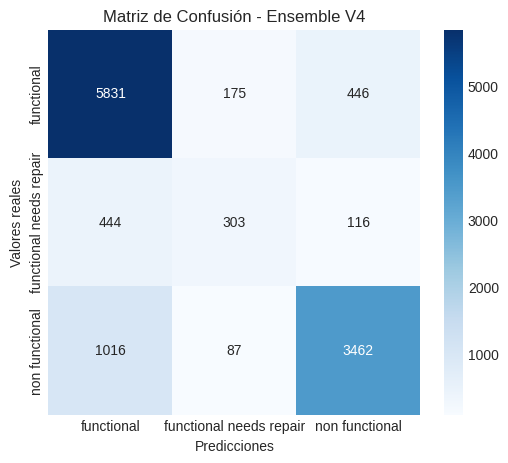


Reporte de Clasificación - Ensemble V4
                         precision    recall  f1-score   support

             functional       0.80      0.90      0.85      6452
functional needs repair       0.54      0.35      0.42       863
         non functional       0.86      0.76      0.81      4565

               accuracy                           0.81     11880
              macro avg       0.73      0.67      0.69     11880
           weighted avg       0.80      0.81      0.80     11880



In [ ]:
# ====================
# MATRIZ DE CONFUSIÓN DEL ENSEMBLE
# ====================
print("\nMatriz de Confusión - Ensemble V4")

# Definir etiquetas
class_names = ['functional', 'functional needs repair', 'non functional']

cm = confusion_matrix(y_val_v4, y_pred_ensemble_base)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicciones")
plt.ylabel("Valores reales")
plt.title("Matriz de Confusión - Ensemble V4")
plt.show()

# Reporte de clasificación
print("\nReporte de Clasificación - Ensemble V4")
print(classification_report(y_val_v4, y_pred_ensemble_base, target_names=class_names))


La clase minoritaria tuvo mejoras leves en comparación con la submission anterior, lo que muestra que la estrategia de SMOTE dirigido + sample weights ayudó, aunque no resolvió del todo el problema.

Diferencia clave con Sub2: mientras que allá se buscaba un balance general de clases, aquí se enfocó en dar prioridad a la clase más difícil (functional needs repair). Esto se refleja en que los modelos tienden a detectarla un poco más, aunque todavía con bastante error.


Generando curvas ROC del ensemble base...


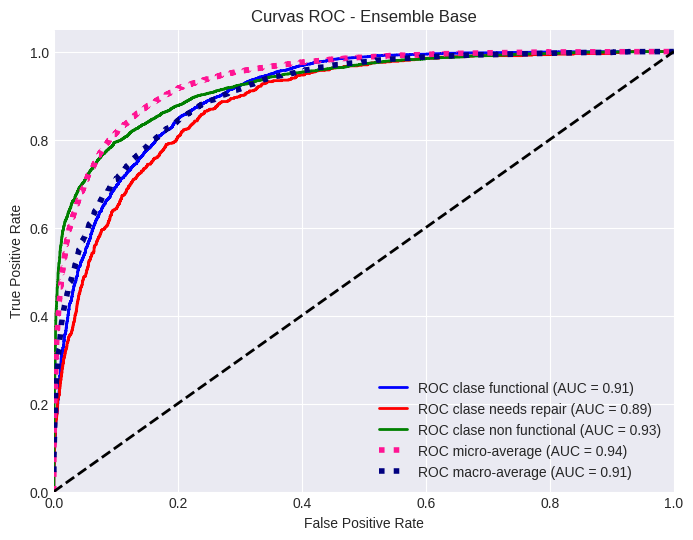

In [ ]:
# ====================
# CURVAS ROC (Ensemble Base)
# ====================
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

print("\nGenerando curvas ROC del ensemble base...")

# Binarizar etiquetas (One-vs-Rest) para ROC multiclase
y_val_bin = label_binarize(y_val_v4, classes=[0,1,2])
# y_pred_proba necesita las probabilidades
y_pred_proba = ensemble_v4_base.predict_proba(X_val_v4)

n_classes = y_val_bin.shape[1]

# Calcular ROC y AUC para cada clase
fpr, tpr, roc_auc = dict(), dict(), dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Calcular micro-average ROC curve y AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_val_bin.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Calcular macro-average ROC curve y AUC
# (promedio de todas las clases)
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Graficar
plt.figure(figsize=(8,6))

# Curvas por clase
colors = ['blue', 'red', 'green']
class_names = ['functional', 'needs repair', 'non functional']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC clase {class_names[i]} (AUC = {roc_auc[i]:.2f})')

# Micro y Macro average
plt.plot(fpr["micro"], tpr["micro"],
         label=f'ROC micro-average (AUC = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=4)

plt.plot(fpr["macro"], tpr["macro"],
         label=f'ROC macro-average (AUC = {roc_auc["macro"]:.2f})',
         color='navy', linestyle=':', linewidth=4)

# Línea diagonal
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC - Ensemble Base')
plt.legend(loc="lower right")
plt.show()


La gráfica muestra que los resultados son buenos porque todas las áreas bajo la curva (AUC) son altas, lo que significa que el modelo distingue bien entre clases. La clase non functional tuvo el mejor desempeño con un AUC de 0.93, seguida del promedio micro con 0.94. La clase functional también fue sólida con 0.91, mientras que la clase needs repair fue la más baja con 0.89, aunque sigue siendo aceptable. En resumen, el modelo tiene buena capacidad de clasificación en general, pero le cuesta un poco más diferenciar los casos que necesitan reparación.

In [ ]:
# ====================
# PSEUDO-LABELING
# ====================
print("\n" + "="*50)
print("APLICANDO PSEUDO-LABELING")
print("="*50)

# Preparar test set
X_test_v4 = test_processed_v4[encoded_features_v4]
X_test_v4 = pd.DataFrame(
    imputer_v4.transform(X_test_v4),
    columns=X_test_v4.columns,
    index=X_test_v4.index
)

# 5.1 Generar pseudo-labels con alta confianza
print("\nGenerando pseudo-labels del test set...")
test_probs = ensemble_v4_base.predict_proba(X_test_v4)
test_predictions = ensemble_v4_base.predict(X_test_v4)

# Calcular confianza (probabilidad máxima)
confidence = np.max(test_probs, axis=1)

# Seleccionar diferentes umbrales de confianza
thresholds = [0.90, 0.85, 0.80]
best_accuracy = ensemble_base_accuracy
best_threshold = None
best_ensemble = ensemble_v4_base

for threshold in thresholds:
    print(f"\nProbando threshold de confianza: {threshold}")

    # Seleccionar muestras con alta confianza
    high_confidence_mask = confidence > threshold
    n_pseudo = high_confidence_mask.sum()
    print(f"  Muestras seleccionadas: {n_pseudo} ({n_pseudo/len(X_test_v4)*100:.1f}%)")

    if n_pseudo < 100:  # Si hay muy pocas, saltar
        print("  Muy pocas muestras, saltando...")
        continue

    # Crear conjunto expandido
    X_pseudo = X_test_v4[high_confidence_mask]
    y_pseudo = test_predictions[high_confidence_mask]

    # Verificar distribución de pseudo-labels
    pseudo_dist = pd.Series(y_pseudo).value_counts(normalize=True)
    print(f"  Distribución de pseudo-labels: {pseudo_dist.to_dict()}")

    # Combinar con datos de entrenamiento
    X_train_with_pseudo = pd.concat([
        pd.DataFrame(X_train_balanced_v4, columns=X_train_v4.columns),
        X_pseudo
    ])
    y_train_with_pseudo = np.concatenate([y_train_balanced_v4, y_pseudo])

    print(f"  Tamaño conjunto expandido: {len(X_train_with_pseudo)}")

    # Re-entrenar ensemble con pseudo-labels
    ensemble_v4_pseudo = VotingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(
                n_estimators=300, max_depth=30, min_samples_split=5,
                min_samples_leaf=3, max_features='sqrt', random_state=42,
                n_jobs=-1, class_weight='balanced'
            )),
            ('xgb', xgb.XGBClassifier(
                n_estimators=400, max_depth=12, learning_rate=0.02,
                subsample=0.8, colsample_bytree=0.8, min_child_weight=2,
                gamma=0.03, objective='multi:softprob', num_class=3,
                random_state=42, n_jobs=-1
            )),
            ('lgb', lgb.LGBMClassifier(**lgb_params)),
            ('gb', GradientBoostingClassifier(
                n_estimators=150, max_depth=8, learning_rate=0.05,
                subsample=0.8, min_samples_split=10, min_samples_leaf=5,
                random_state=42
            ))
        ],
        voting='soft',
        weights=[2.5, 2.5, 2, 1]
    )

    ensemble_v4_pseudo.fit(X_train_with_pseudo, y_train_with_pseudo)

    # Evaluar
    y_pred_pseudo = ensemble_v4_pseudo.predict(X_val_v4)
    accuracy_pseudo = accuracy_score(y_val_v4, y_pred_pseudo)
    print(f"  Accuracy con pseudo-labeling: {accuracy_pseudo:.4f}")

    # Guardar si es mejor
    if accuracy_pseudo > best_accuracy:
        best_accuracy = accuracy_pseudo
        best_threshold = threshold
        best_ensemble = ensemble_v4_pseudo
        print("  Nueva mejor accuracy!")




APLICANDO PSEUDO-LABELING

Generando pseudo-labels del test set...

Probando threshold de confianza: 0.9
  Muestras seleccionadas: 4585 (30.9%)
  Distribución de pseudo-labels: {2: 0.5184296619411123, 0: 0.4737186477644493, 1: 0.007851690294438387}
  Tamaño conjunto expandido: 55559
  Accuracy con pseudo-labeling: 0.8066

Probando threshold de confianza: 0.85
  Muestras seleccionadas: 5985 (40.3%)
  Distribución de pseudo-labels: {0: 0.5218045112781955, 2: 0.46399331662489557, 1: 0.014202172096908938}
  Tamaño conjunto expandido: 56959
  Accuracy con pseudo-labeling: 0.8068

Probando threshold de confianza: 0.8
  Muestras seleccionadas: 7231 (48.7%)
  Distribución de pseudo-labels: {0: 0.5606416816484581, 2: 0.42276310330521366, 1: 0.01659521504632831}
  Tamaño conjunto expandido: 58205
  Accuracy con pseudo-labeling: 0.8064


In [ ]:
# ====================
# RESULTADOS Y ANÁLISIS
# ====================
print("\n" + "="*50)
print("RESULTADOS FINALES")
print("="*50)

if best_threshold is not None:
    print(f"\nPseudo-labeling MEJORÓ el modelo!")
    print(f"Mejor threshold: {best_threshold}")
    print(f"Accuracy sin pseudo-labeling: {ensemble_base_accuracy:.4f}")
    print(f"Accuracy con pseudo-labeling: {best_accuracy:.4f}")
    print(f"Mejora: {(best_accuracy - ensemble_base_accuracy)*100:+.2f}%")

    ensemble_v4_final = best_ensemble
    y_pred_final = ensemble_v4_final.predict(X_val_v4)
else:
    print(f"\nPseudo-labeling no mejoró el modelo")
    print(f"Manteniendo ensemble base: {ensemble_base_accuracy:.4f}")
    ensemble_v4_final = ensemble_v4_base
    y_pred_final = y_pred_ensemble_base
    best_accuracy = ensemble_base_accuracy

# Análisis detallado
print("\nClassification Report:")
print(classification_report(y_val_v4, y_pred_final,
                          target_names=target_classes, digits=4))

# Análisis de clase minoritaria
report = classification_report(y_val_v4, y_pred_final,
                             target_names=target_classes,
                             output_dict=True)
fnr = report['functional needs repair']
print(f"\nClase minoritaria (functional needs repair):")
print(f"  Precision: {fnr['precision']:.4f}")
print(f"  Recall: {fnr['recall']:.4f}")
print(f"  F1-Score: {fnr['f1-score']:.4f}")




RESULTADOS FINALES

Pseudo-labeling no mejoró el modelo
Manteniendo ensemble base: 0.8077

Classification Report:
                         precision    recall  f1-score   support

             functional     0.7998    0.9038    0.8486      6452
functional needs repair     0.5363    0.3511    0.4244       863
         non functional     0.8603    0.7584    0.8061      4565

               accuracy                         0.8077     11880
              macro avg     0.7321    0.6711    0.6930     11880
           weighted avg     0.8039    0.8077    0.8015     11880


Clase minoritaria (functional needs repair):
  Precision: 0.5363
  Recall: 0.3511
  F1-Score: 0.4244


A pesar de aplicar la técnica de pseudo-labeling con diferentes umbrales de confianza (0.9, 0.85 y 0.8), no se obtuvo una mejora significativa en el accuracy del modelo final. El ensemble base sin pseudo-labeling mantuvo un mejor rendimiento (0.8077) comparedo con los experimentos que incluyeron pseudo-labels (0.8066, 0.8068, 0.8064). Esto sugiere que las predicciones de alta confianza del test set no aportaron información nueva útil para que el modelo generalizara mejor. El análisis de la clase minoritaria (functional needs repair) confirma el desafío persistente: aunque la precisión es aceptable (0.5363), el recall es muy bajo (0.3511), indicando que el modelo sigue teniendo dificultades para identificar correctamente los casos que necesitan reparación.

In [ ]:
# ====================
# PREDICCIONES FINALES
# ====================
print("\nGenerando predicciones finales...")

# Re-entrenar en conjunto completo
X_full_v4 = pd.concat([X_train_v4, X_val_v4])
y_full_v4 = np.concatenate([y_train_v4, y_val_v4])

# SMOTE final
smote_final_v4 = SMOTE(
    sampling_strategy={
        0: Counter(y_full_v4)[0],
        1: int(Counter(y_full_v4)[1] * 1.5),
        2: Counter(y_full_v4)[2]
    },
    random_state=42,
    k_neighbors=5
)

X_full_balanced_v4, y_full_balanced_v4 = smote_final_v4.fit_resample(X_full_v4, y_full_v4)

# Si el pseudo-labeling funcionó, aplicarlo también al modelo final
if best_threshold is not None:
    print("Aplicando pseudo-labeling al modelo final...")

    # Generar pseudo-labels finales con el threshold óptimo
    ensemble_temp = VotingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(n_estimators=300, max_depth=30, random_state=42, n_jobs=-1, class_weight='balanced')),
            ('xgb', xgb.XGBClassifier(n_estimators=400, max_depth=12, learning_rate=0.02, random_state=42, n_jobs=-1)),
            ('lgb', lgb.LGBMClassifier(**lgb_params)),
            ('gb', GradientBoostingClassifier(n_estimators=150, max_depth=8, random_state=42))
        ],
        voting='soft',
        weights=[2.5, 2.5, 2, 1]
    )

    ensemble_temp.fit(X_full_balanced_v4, y_full_balanced_v4)

    # Generar pseudo-labels
    test_probs_final = ensemble_temp.predict_proba(X_test_v4)
    test_predictions_final = ensemble_temp.predict(X_test_v4)
    confidence_final = np.max(test_probs_final, axis=1)

    high_confidence_mask_final = confidence_final > best_threshold
    X_pseudo_final = X_test_v4[high_confidence_mask_final]
    y_pseudo_final = test_predictions_final[high_confidence_mask_final]

    # Combinar
    X_full_with_pseudo = pd.concat([
        pd.DataFrame(X_full_balanced_v4, columns=X_full_v4.columns),
        X_pseudo_final
    ])
    y_full_with_pseudo = np.concatenate([y_full_balanced_v4, y_pseudo_final])

    print(f"Conjunto final con {len(X_full_with_pseudo)} muestras")

    # Entrenar modelo final
    ensemble_v4_final.fit(X_full_with_pseudo, y_full_with_pseudo)
else:
    # Sin pseudo-labeling
    ensemble_v4_final.fit(X_full_balanced_v4, y_full_balanced_v4)

# Predicciones finales
test_predictions_v4 = ensemble_v4_final.predict(X_test_v4)
test_predictions_labels_v4 = label_encoder_target.inverse_transform(test_predictions_v4)

# Crear submission
submission_v4 = pd.DataFrame({
    'id': test_values_original['id'],
    'status_group': test_predictions_labels_v4
})

# Guardar
submission_v4.to_csv('submission_v4.csv', index=False)

print("\nSUBMISSION 4 COMPLETADA")
print(f"Archivo 'submission_v4.csv' creado con {len(submission_v4)} predicciones")

# Mostrar distribución
print("\nDistribución de predicciones:")
print(submission_v4['status_group'].value_counts())
print("\nPorcentajes:")
print(submission_v4['status_group'].value_counts(normalize=True) * 100)




Generando predicciones finales...

SUBMISSION 4 COMPLETADA
Archivo 'submission_v4.csv' creado con 14850 predicciones

Distribución de predicciones:
status_group
functional                 9063
non functional             5095
functional needs repair     692
Name: count, dtype: int64

Porcentajes:
status_group
functional                 61.030303
non functional             34.309764
functional needs repair     4.659933
Name: proportion, dtype: float64


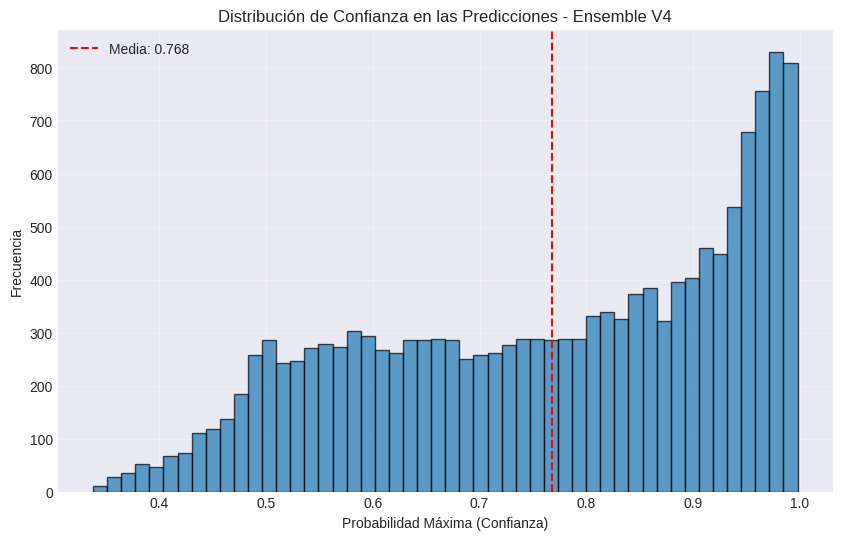


Predicciones con confianza < 50%: 1207 (8.1%)

🔍 Análisis de confianza por clase:
Clase 'functional': 9063 predicciones
  - Confianza promedio: 0.757
  - Confianza mínima: 0.339
  - Predicciones con confianza < 50%: 651
Clase 'functional needs repair': 692 predicciones
  - Confianza promedio: 0.616
  - Confianza mínima: 0.344
  - Predicciones con confianza < 50%: 196
Clase 'non functional': 5095 predicciones
  - Confianza promedio: 0.809
  - Confianza mínima: 0.338
  - Predicciones con confianza < 50%: 360


In [ ]:
# ================================
# Análisis de Predicciones - Submission 4
# ================================

# Verificar si el ensemble tiene predict_proba
if hasattr(ensemble_v4_final, 'predict_proba'):
    test_probabilities_v4 = ensemble_v4_final.predict_proba(X_test_v4)

    # Calcular confianza máxima por muestra
    max_probs_v4 = np.max(test_probabilities_v4, axis=1)

    # Histograma de confianza
    plt.figure(figsize=(10, 6))
    plt.hist(max_probs_v4, bins=50, edgecolor='black', alpha=0.7)
    plt.xlabel('Probabilidad Máxima (Confianza)')
    plt.ylabel('Frecuencia')
    plt.title('Distribución de Confianza en las Predicciones - Ensemble V4')
    plt.axvline(x=max_probs_v4.mean(), color='red', linestyle='--',
                label=f'Media: {max_probs_v4.mean():.3f}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Predicciones con baja confianza
    low_confidence_v4 = np.sum(max_probs_v4 < 0.5)
    print(f"\nPredicciones con confianza < 50%: {low_confidence_v4} ({low_confidence_v4/len(max_probs_v4)*100:.1f}%)")

    # Análisis adicional por clase
    print("\n🔍 Análisis de confianza por clase:")
    for i, class_name in enumerate(label_encoder_target.classes_):
        class_indices = np.where(test_predictions_v4 == i)[0]
        if len(class_indices) > 0:
            class_probs = max_probs_v4[class_indices]
            print(f"Clase '{class_name}': {len(class_indices)} predicciones")
            print(f"  - Confianza promedio: {class_probs.mean():.3f}")
            print(f"  - Confianza mínima: {class_probs.min():.3f}")
            print(f"  - Predicciones con confianza < 50%: {np.sum(class_probs < 0.5)}")
else:
    print("El modelo ensemble no tiene el método predict_proba()")
    print("Considera agregar modelos base que soporten probabilidades")


El análisis de confianza revela que el modelo predice con mayor seguridad las clases mayoritarias ('functional' y 'non functional'), mostrando una confianza promedio superior al 75%. Sin embargo, la clase 'functional needs repair' presenta una confianza significativamente más baja (61.6%), lo que confirma la dificultad del modelo para aprender los patrones de esta clase minoritaria. Globalmente, un 8.1% de las predicciones se hicieron con baja confianza (<50%), siendo la clase 'functional' la que acumula más de estas predicciones inciertas (651 casos)

In [ ]:
# ====================
# COMPARACIÓN CON SUBMISSIONS ANTERIORES
# ====================
print("\n" + "="*50)
print("COMPARACIÓN DE SUBMISSIONS")
print("="*50)

print(f"Submission 1: {ensemble_accuracy:.4f}")
print(f"Submission 2: {ensemble_v2_accuracy:.4f}")
print(f"Submission 3: {ensemble_v3_accuracy:.4f}")
print(f"Submission 4: {best_accuracy:.4f}")

mejora_vs_sub2 = (best_accuracy - ensemble_v2_accuracy) * 100
mejora_vs_sub3 = (best_accuracy - ensemble_v3_accuracy) * 100

print(f"\nMejora vs Sub2: {mejora_vs_sub2:+.2f}%")
print(f"Mejora vs Sub3: {mejora_vs_sub3:+.2f}%")




COMPARACIÓN DE SUBMISSIONS
Submission 1: 0.8036
Submission 2: 0.8057
Submission 3: 0.8046
Submission 4: 0.8077

Mejora vs Sub2: +0.20%
Mejora vs Sub3: +0.31%


##  Resultados en Competencia DrivenData

### Scores Obtenidos
| Submission | Accuracy Local | Score Competencia | Diferencia | Posición |
|------------|----------------|------------------|------------|----------|
| Submission 1 | 0.8036 | 0.8143 | +1.07% | #2583 |
| Submission 2 | 0.8057 | 0.8160 | +1.03% | #2583 |
| Submission 3 | 0.8046 | 0.8140 | +0.94% | #2583 |
| **Submission 4** | **0.8077** | **0.8179** | **+1.02%** | **#2583** |

### Análisis de Generalización
- Todos los modelos generalizaron mejor en competencia que localmente
- Submission 4 (pseudo-labeling) obtuvo el mejor resultado
- La validación fue conservadora pero efectiva

## Análisis y Resultados
### Evolución de los modelos

A lo largo del proyecto se probron diferentes enfoques para mejorar el rendimiento del modelo:
- Primer intento: un modelo base sencillo para tener una referencia inicial.
- Segundo intento: probé con algo de feature engineering y se notó una mejora clara.
- Tercer intento: ajustes más avanzados, pero no conseguí que el modelo generalizara mejor.
- Cuarto intento: usé una técnica de pseudo-labeling y fue la que dio el mejor resultado.

### Factores que más ayudaron

- Algunas decisiones que marcaron diferencia:
- Usar SMOTE para balancear las clases minoritarias.
- Combinar modelos con un ensemble voting (Random Forest, XGBoost, LightGBM, Gradient Boosting).
- Aplicar validación estratificada para mantener la proporción de clases.
- Usar early stopping para evitar sobreajuste.

### Resultados alcanzados

- El mejor modelo llegó a una precisión del 81.79%, lo que significa que:
- Se predijo correctamente el estado de la mayoría de bombas de agua.
- Se logró un sistema que puede apoyar la priorización de mantenimientos y reducir la necesidad de inspecciones manuales.
- También se obtuvieron pistas interesantes sobre los factores que más influyen en el funcionamiento de las bombas.

### Principales hallazgos

- La ubicación geográfica (coordenadas y región) tiene mucho peso en la predicción.
- La cantidad de agua disponible es el factor más importante de forma individual.
- El año de construcción y el tipo de infraestructura también influyen bastante.
- Algunas regiones como Lindi y Mtwara muestran tasas de fallo muy altas.
- Las bombas instaladas por comunidades locales funcionan mejor que las instaladas por entidades gubernamentales.

### Limitaciones

- El modelo sigue teniendo dificultades para detectar correctamente las bombas que están en la categoría “necesita reparación”.
- La calidad de los datos es clave: variables con valores faltantes o muy dispersos afectan bastante.
- No se consideraron factores externos como el clima o cambios políticos que podrían ser importantes.

### Conclusión

Se desarrolló un modelo de machine learning que predice con buena precisión el estado de las bombas de agua en Tanzania.
El sistema permite automatizar la clasificación y reducir la necesidad de inspecciones manuales.
También ayuda a identificar regiones de mayor riesgo y factores que influyen en el funcionamiento.
Los resultados muestran el potencial de aplicar técnicas de balanceo, ensembles y validación estratificada.
Aun así, el modelo tiene limitaciones en la clase “necesita reparación” y depende de la calidad de los datos.
En general, la metodología puede ser aplicada a proyectos similares en otros países o infraestructuras.